# <font color='#26CCC2'>This notebook is to analyze the AGN data from Chenxu: Normalized</font>
The notebook uses data from the get_spec_example file to:
- Work with the spectra (make adjustments and clean up)
- Look at spectra over wavelength
- Fit spectral lines
- Find BH Mass

## <font color='#FF76CE' size=5 >Imports</font>

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, differential_evolution, minimize
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors


## <font color='#FF76CE' size=5 >Plot Set Up</font>

In [2]:
# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})


## <font color='#FF76CE' size=5 >Definitions</font>

In [3]:
# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23}, 
]

# Galaxies from Reines 2013 https://iopscience.iop.org/article/10.1088/0004-637X/813/2/82
galaxiesWithAGNBHMasses_Reines = [
    {"name": "SDSS J000907.90+142755.8", "logMs": 10.68, "logMBH": 6.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J004236.86-104922.0", "logMs": 10.43, "logMBH": 7.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J012159.81-010224.3", "logMs": 10.47, "logMBH": 7.65, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J021011.49-090335.5", "logMs": 10.92, "logMBH": 8.11, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J024912.86-081525.7", "logMs": 10.11, "logMBH": 5.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J030417.77+002827.2", "logMs": 10.61, "logMBH": 6.50, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J032006.32+402158.6", "logMs": 10.36, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J040929.15-042902.7", "logMs": 9.64, "logMBH": 6.76, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J073106.44+392639.9", "logMs": 10.58, "logMBH": 6.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075151.87+494851.9", "logMs": 10.61, "logMBH": 6.51, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075243.60+455655.9", "logMs": 11.49, "logMBH": 7.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075525.28+391109.8", "logMs": 10.19, "logMBH": 6.74, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075643.72+445124.1", "logMs": 10.70, "logMBH": 6.82, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075850.28+093520.7", "logMs": 10.96, "logMBH": 7.25, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075941.30+505022.9", "logMs": 10.31, "logMBH": 7.11, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080020.98+263648.8", "logMs": 11.05, "logMBH": 6.99, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080243.40+310403.3", "logMs": 10.47, "logMBH": 7.80, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080538.89+261003.0", "logMs": 10.51, "logMBH": 6.59, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080545.71+073526.2", "logMs": 11.30, "logMBH": 7.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080707.17+361400.5", "logMs": 10.93, "logMBH": 5.83, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080801.75+381935.3", "logMs": 10.09, "logMBH": 6.46, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080910.72+110619.1", "logMs": 10.05, "logMBH": 6.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081319.32+460849.6", "logMs": 10.81, "logMBH": 7.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081516.87+460430.8", "logMs": 10.93, "logMBH": 6.75, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081718.55+520148.1", "logMs": 9.70, "logMBH": 6.48, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081726.41+101210.1", "logMs": 10.35, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082442.80+295920.9", "logMs": 9.77, "logMBH": 5.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082510.23+375919.7", "logMs": 10.31, "logMBH": 6.28, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082620.81+055727.8", "logMs": 10.64, "logMBH": 6.88, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082818.67+573912.9", "logMs": 11.11, "logMBH": 7.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082842.73+454433.2", "logMs": 10.40, "logMBH": 7.05, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082912.66+500652.6", "logMs": 9.09, "logMBH": 6.26, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J083732.60+284221.9", "logMs": 10.77, "logMBH": 6.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J083810.94+245342.9", "logMs": 11.12, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J084137.86+545506.8", "logMs": 10.84, "logMBH": 6.99, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J084143.50+013149.8", "logMs": 11.29, "logMBH": 6.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J084654.09+252212.3", "logMs": 10.13, "logMBH": 7.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J090613.75+561015.5", "logMs": 9.30, "logMBH": 5.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J090902.35+133019.4", "logMs": 10.69, "logMBH": 7.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091101.33+571247.1", "logMs": 10.54, "logMBH": 7.01, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091102.32+550023.3", "logMs": 10.14, "logMBH": 5.98, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091256.44+380538.0", "logMs": 9.95, "logMBH": 7.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091424.75+115625.5", "logMs": 10.01, "logMBH": 5.68, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091520.48+411918.8", "logMs": 10.52, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091634.32+175508.3", "logMs": 10.68, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091913.18+552755.2", "logMs": 9.76, "logMBH": 6.95, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092115.56+101741.0", "logMs": 10.67, "logMBH": 7.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092438.89+560743.0", "logMs": 10.80, "logMBH": 6.56, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092528.24+233631.0", "logMs": 11.00, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092603.26+124403.7", "logMs": 10.26, "logMBH": 7.23, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092740.77+262701.1", "logMs": 10.52, "logMBH": 6.31, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093206.90+172703.2", "logMs": 9.88, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093327.87+093200.0", "logMs": 10.37, "logMBH": 7.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093408.59+175644.0", "logMs": 9.76, "logMBH": 5.81, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093410.88+305657.9", "logMs": 10.75, "logMBH": 7.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094204.79+234106.9", "logMs": 10.14, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094328.71+524811.7", "logMs": 10.65, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094529.36+093610.4", "logMs": 9.59, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094838.42+403043.7", "logMs": 10.66, "logMBH": 7.32, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094839.73+363649.3", "logMs": 10.60, "logMBH": 6.67, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094852.56+285338.4", "logMs": 10.83, "logMBH": 7.00, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095220.09+322826.8", "logMs": 10.57, "logMBH": 6.41, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095437.22+063719.5", "logMs": 10.90, "logMBH": 7.76, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095540.47+050236.5", "logMs": 10.67, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095745.49+152350.6", "logMs": 10.35, "logMBH": 6.56, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095800.22+154722.0", "logMs": 10.71, "logMBH": 6.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095956.09+130235.9", "logMs": 10.61, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100207.03+030327.6", "logMs": 10.59, "logMBH": 7.22, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100218.78+264805.7", "logMs": 10.96, "logMBH": 7.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100510.50+543255.7", "logMs": 10.24, "logMBH": 5.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100819.11+372903.4", "logMs": 11.24, "logMBH": 6.65, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100854.93+373929.9", "logMs": 10.20, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101202.59+301303.0", "logMs": 10.20, "logMBH": 7.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101718.70+291432.0", "logMs": 10.25, "logMBH": 6.98, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101846.01+345007.9", "logMs": 10.24, "logMBH": 6.28, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101913.90+635759.0", "logMs": 10.47, "logMBH": 7.58, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102306.97+125100.3", "logMs": 10.34, "logMBH": 6.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102402.40+062942.0", "logMs": 10.11, "logMBH": 6.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102532.09+102503.9", "logMs": 10.89, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102841.98+490418.6", "logMs": 10.91, "logMBH": 6.88, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J103234.30+650224.9", "logMs": 9.89, "logMBH": 5.63, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J103438.59+393828.2", "logMs": 10.22, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J103751.81+334850.1", "logMs": 10.90, "logMBH": 6.43, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104120.48+314039.1", "logMs": 10.27, "logMBH": 6.89, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104252.93+041441.1", "logMs": 10.21, "logMBH": 7.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104438.89+384527.9", "logMs": 11.08, "logMBH": 6.81, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104451.72+063548.6", "logMs": 10.96, "logMBH": 6.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104504.23+114508.7", "logMs": 10.17, "logMBH": 6.59, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J105415.52+174522.5", "logMs": 10.69, "logMBH": 6.94, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J105427.88+330943.4", "logMs": 10.18, "logMBH": 6.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J105658.52+441653.1", "logMs": 10.11, "logMBH": 7.53, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110016.03+461615.3", "logMs": 9.76, "logMBH": 6.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110032.29+020656.0", "logMs": 11.26, "logMBH": 7.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110158.30+101740.9", "logMs": 9.73, "logMBH": 7.32, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110422.05+321404.5", "logMs": 9.86, "logMBH": 6.74, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110807.47+270602.7", "logMs": 10.33, "logMBH": 6.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110929.00+284132.9", "logMs": 10.18, "logMBH": 5.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111045.96+113641.5", "logMs": 11.05, "logMBH": 7.18, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111227.30+184926.8", "logMs": 10.38, "logMBH": 7.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111349.74+093510.7", "logMs": 10.66, "logMBH": 7.19, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111752.64+291816.1", "logMs": 10.23, "logMBH": 6.85, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111857.69+580323.9", "logMs": 9.96, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112423.88+274245.3", "logMs": 10.48, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112536.89+542256.0", "logMs": 9.94, "logMBH": 7.27, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112545.34+240823.9", "logMs": 10.36, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112628.71+472453.8", "logMs": 10.16, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112637.74+513423.2", "logMs": 10.14, "logMBH": 5.99, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112842.51+195313.2", "logMs": 10.39, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112942.76+555913.1", "logMs": 10.42, "logMBH": 6.33, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J113240.25+525701.6", "logMs": 10.36, "logMBH": 6.48, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J113249.27+101747.2", "logMs": 11.31, "logMBH": 7.63, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J113549.07+565708.4", "logMs": 11.14, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114013.94+244149.4", "logMs": 10.81, "logMBH": 7.00, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114054.08+230744.3", "logMs": 10.05, "logMBH": 7.25, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114430.09+365259.9", "logMs": 10.90, "logMBH": 8.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114433.05+613201.0", "logMs": 11.10, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114444.89+331915.4", "logMs": 10.65, "logMBH": 5.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114530.30+094352.0", "logMs": 10.47, "logMBH": 6.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114545.18+554759.9", "logMs": 11.04, "logMBH": 7.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114740.08+334720.4", "logMs": 10.74, "logMBH": 6.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J115138.10+561332.1", "logMs": 9.80, "logMBH": 6.18, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J115710.68+221746.2", "logMs": 10.76, "logMBH": 7.30, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120114.35-034041.1", "logMs": 9.54, "logMBH": 6.96, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120144.91+201941.9", "logMs": 10.70, "logMBH": 6.17, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120208.36+174124.8", "logMs": 10.18, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120257.81+045045.0", "logMs": 10.71, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120429.79+201901.0", "logMs": 10.81, "logMBH": 6.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120440.50+311100.0", "logMs": 10.95, "logMBH": 7.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120626.27+424426.0", "logMs": 10.62, "logMBH": 7.33, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120727.97+253610.9", "logMs": 10.47, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120929.16+330530.1", "logMs": 10.10, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121044.27+382010.2", "logMs": 10.43, "logMBH": 7.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121607.08+504930.4", "logMs": 10.71, "logMBH": 8.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121826.72-000750.1", "logMs": 9.93, "logMBH": 6.56, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121905.27+210632.6", "logMs": 11.05, "logMBH": 7.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121923.73+303002.7", "logMs": 9.90, "logMBH": 5.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J122215.37+282123.7", "logMs": 9.63, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J122342.82+581446.4", "logMs": 9.29, "logMBH": 6.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J122548.86+333248.7", "logMs": 8.90, "logMBH": 5.00, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123237.48+662452.5", "logMs": 10.61, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123454.70+153410.9", "logMs": 10.74, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123650.90+453902.9", "logMs": 10.54, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123741.18+264227.5", "logMs": 9.81, "logMBH": 5.86, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123838.10+453414.4", "logMs": 10.80, "logMBH": 6.54, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J124145.71+320256.2", "logMs": 10.09, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J124345.79+193846.4", "logMs": 10.10, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J124610.76+275615.9", "logMs": 10.23, "logMBH": 7.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125042.20-024928.9", "logMs": 10.71, "logMBH": 7.39, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125400.20+424220.0", "logMs": 10.90, "logMBH": 6.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125552.36+103055.2", "logMs": 10.61, "logMBH": 7.19, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125710.75+272417.6", "logMs": 10.27, "logMBH": 6.11, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130019.94+613918.4", "logMs": 10.72, "logMBH": 7.60, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130342.82+324824.5", "logMs": 9.57, "logMBH": 6.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130615.16+585733.4", "logMs": 9.59, "logMBH": 6.65, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130721.92+095209.3", "logMs": 10.79, "logMBH": 7.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130803.88+505227.0", "logMs": 10.28, "logMBH": 6.27, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J131305.81+012755.9", "logMs": 10.35, "logMBH": 6.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J131310.12+051942.1", "logMs": 9.89, "logMBH": 5.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J131905.95+310852.7", "logMs": 10.55, "logMBH": 6.67, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132255.43+080941.5", "logMs": 10.64, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132507.32+082026.4", "logMs": 10.65, "logMBH": 6.34, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132731.12+244641.0", "logMs": 10.83, "logMBH": 7.71, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132908.83+295024.1", "logMs": 9.81, "logMBH": 6.58, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J133739.87+390916.4", "logMs": 10.45, "logMBH": 6.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134208.38+353915.5", "logMs": 10.26, "logMBH": 6.77, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134300.79+360956.3", "logMs": 9.68, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134426.41+441620.0", "logMs": 10.27, "logMBH": 6.82, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134632.13+642325.2", "logMs": 9.67, "logMBH": 6.30, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134704.35+110622.6", "logMs": 10.75, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134812.56+072340.7", "logMs": 10.52, "logMBH": 6.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134952.60+020440.0", "logMs": 10.22, "logMBH": 7.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J135317.78+332927.0", "logMs": 10.43, "logMBH": 5.47, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J140018.41+050242.2", "logMs": 10.73, "logMBH": 7.33, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J140514.86-025901.2", "logMs": 10.67, "logMBH": 7.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141415.17+264451.4", "logMs": 10.57, "logMBH": 7.27, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141630.82+013708.0", "logMs": 11.00, "logMBH": 7.22, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141759.54+250812.7", "logMs": 10.80, "logMBH": 7.94, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141920.64+043623.3", "logMs": 10.96, "logMBH": 6.61, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J142138.63+173536.2", "logMs": 10.42, "logMBH": 7.58, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J142408.38+210518.5", "logMs": 10.78, "logMBH": 7.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J142817.98+571018.6", "logMs": 10.59, "logMBH": 6.90, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J143450.63+033842.5", "logMs": 10.14, "logMBH": 5.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J143452.46+483942.7", "logMs": 10.10, "logMBH": 7.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J144431.62+153643.2", "logMs": 10.53, "logMBH": 7.12, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145037.85+224403.6", "logMs": 9.84, "logMBH": 6.55, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145055.43+273442.7", "logMs": 10.91, "logMBH": 6.79, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145314.29+170037.9", "logMs": 10.60, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145518.40+163253.7", "logMs": 10.49, "logMBH": 6.12, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145631.35+212030.0", "logMs": 10.03, "logMBH": 6.55, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145819.55+045451.7", "logMs": 10.09, "logMBH": 7.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150138.79+102513.4", "logMs": 10.59, "logMBH": 7.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150311.67+111027.3", "logMs": 10.25, "logMBH": 6.85, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150744.40+512703.0", "logMs": 11.24, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150853.94-001149.0", "logMs": 11.06, "logMBH": 7.45, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151150.03+075918.7", "logMs": 10.37, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151343.31+042143.6", "logMs": 10.56, "logMBH": 6.96, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151621.58+080604.6", "logMs": 10.41, "logMBH": 6.24, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151634.45+205837.9", "logMs": 9.88, "logMBH": 5.98, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151907.55+260750.6", "logMs": 10.39, "logMBH": 6.53, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J152324.43+551855.5", "logMs": 10.70, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J152416.66+045119.0", "logMs": 10.46, "logMBH": 7.20, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J152940.58+302909.3", "logMs": 10.74, "logMBH": 6.97, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J153118.01+072740.3", "logMs": 10.83, "logMBH": 7.61, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J153146.89+062257.9", "logMs": 10.71, "logMBH": 7.47, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J153552.50+143103.8", "logMs": 10.29, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154214.26+095654.7", "logMs": 9.57, "logMBH": 6.51, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154241.59+225251.0", "logMs": 11.07, "logMBH": 7.24, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154507.69+170955.0", "logMs": 10.35, "logMBH": 7.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154814.75+450027.7", "logMs": 9.70, "logMBH": 6.48, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155224.87+041726.2", "logMs": 9.29, "logMBH": 6.45, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155417.43+323837.9", "logMs": 10.28, "logMBH": 7.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155640.90+121717.9", "logMs": 10.43, "logMBH": 6.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155807.97+120413.0", "logMs": 10.41, "logMBH": 6.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155926.11+521235.5", "logMs": 10.45, "logMBH": 7.31, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160502.46+330545.0", "logMs": 10.13, "logMBH": 7.80, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160515.85+174227.4", "logMs": 10.46, "logMBH": 6.50, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160558.11+440319.5", "logMs": 10.87, "logMBH": 6.89, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160652.16+275539.1", "logMs": 10.95, "logMBH": 7.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160836.37+121951.5", "logMs": 10.71, "logMBH": 7.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161156.31+521117.1", "logMs": 10.30, "logMBH": 7.26, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161745.63+060353.5", "logMs": 9.99, "logMBH": 7.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161809.60+362002.0", "logMs": 9.60, "logMBH": 6.20, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161844.85+253907.6", "logMs": 10.94, "logMBH": 7.20, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161951.31+405847.3", "logMs": 10.59, "logMBH": 6.78, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J162138.10+351617.3", "logMs": 10.50, "logMBH": 6.90, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J162345.88+410456.4", "logMs": 10.07, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J162501.43+241547.3", "logMs": 10.43, "logMBH": 6.95, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J163007.39-001136.4", "logMs": 10.76, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J163257.50+115040.1", "logMs": 10.28, "logMBH": 6.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J163453.66+231242.6", "logMs": 10.76, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J165601.60+211241.1", "logMs": 10.81, "logMBH": 7.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J170938.94+630635.0", "logMs": 10.04, "logMBH": 7.24, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J171228.44+355302.6", "logMs": 10.85, "logMBH": 6.97, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J172239.93+305252.6", "logMs": 11.02, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J204745.25-052515.6", "logMs": 10.66, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J210533.44+002829.2", "logMs": 9.85, "logMBH": 6.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J212954.56+101603.8", "logMs": 10.61, "logMBH": 6.42, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J213344.25-081615.6", "logMs": 10.89, "logMBH": 7.57, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J213741.44+005317.0", "logMs": 10.99, "logMBH": 6.82, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J215226.03-081024.9", "logMs": 10.67, "logMBH": 6.32, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J215512.41+005906.7", "logMs": 10.51, "logMBH": 6.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J224824.63+000920.6", "logMs": 10.26, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J231815.67+001540.2", "logMs": 11.12, "logMBH": 7.05, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J233837.09-002810.4", "logMs": 10.03, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
];


# Reines 2015 data
Reines_2013_Redshifts = np.array([0.0422, 0.0424, 0.0548, 0.0419, 0.0296, 0.0447, 0.0479, 0.0388, 0.0486, 0.0247, 
                                  0.052, 0.0333, 0.0502, 0.0455, 0.0547, 0.0267, 0.041, 0.0179, 0.0529, 0.0324, 
                                  0.0413, 0.0524, 0.0539, 0.0413, 0.0389, 0.0455, 0.0254, 0.0215, 0.0444, 0.0471, 
                                  0.0493, 0.0435, 0.0124, 0.0285, 0.0449, 0.0495, 0.0506, 0.047, 0.0495, 0.0464, 
                                  0.0447, 0.0455, 0.0309, 0.0499, 0.0268, 0.0493, 0.039, 0.0254, 0.0327, 0.0284, 
                                  0.0484, 0.0511, 0.0493, 0.0269, 0.051, 0.0211, 0.0475, 0.0137, 0.0469, 0.0499, 
                                  0.0468, 0.043, 0.0405, 0.0339, 0.0515, 0.051, 0.0348, 0.0228, 0.0518, 0.0502, 
                                  0.0524, 0.0535, 0.0497, 0.0488, 0.0351, 0.042, 0.0467, 0.0433, 0.0456, 0.0431, 
                                  0.0069, 0.0431, 0.051, 0.0354, 0.0519, 0.0357, 0.0271, 0.0543, 0.037, 0.0433, 
                                  0.0526, 0.0315, 0.0388, 0.0336, 0.0314, 0.0441, 0.0327, 0.0417, 0.0518, 0.0288, 
                                  0.0232, 0.0282, 0.0322, 0.021, 0.0235, 0.0331, 0.0267, 0.0515, 0.0491, 0.0267, 
                                  0.0432, 0.0517, 0.0127, 0.0348, 0.0381, 0.0484, 0.031, 0.021, 0.054, 0.0308, 
                                  0.0511, 0.052, 0.0193, 0.0233, 0.0215, 0.0205, 0.0223, 0.0249, 0.0522, 0.0481,
                                  0.0303, 0.0229, 0.0313, 0.0499, 0.0511, 0.0283, 0.0277, 0.0139, 0.0019, 0.0473, 
                                  0.0455, 0.0305, 0.0208, 0.0407, 0.0504, 0.0533, 0.023, 0.0465, 0.0541, 0.048, 
                                  0.0207, 0.0526, 0.0368, 0.0296, 0.0487, 0.0546, 0.0288, 0.0484, 0.032, 0.0496, 
                                  0.0528, 0.0442, 0.0476, 0.0202, 0.0044, 0.0238, 0.0546, 0.0247, 0.0225, 0.023, 
                                  0.0325, 0.008, 0.0338, 0.0535, 0.0349, 0.0536, 0.0167, 0.0545, 0.0498, 0.0471, 
                                  0.0433, 0.028, 0.037, 0.0495, 0.021, 0.0303, 0.0437, 0.0442, 0.044, 0.035, 
                                  0.0302, 0.0427, 0.0464, 0.054, 0.0454, 0.0375, 0.0308, 0.0398, 0.0449, 0.0394, 
                                  0.0354, 0.0359, 0.0336, 0.0419, 0.0197, 0.0504, 0.0353, 0.0484, 0.0375, 0.0456, 
                                  0.0486, 0.0355, 0.0153, 0.043, 0.0532, 0.0317, 0.0445, 0.0463, 0.0335, 0.0416, 
                                  0.0379, 0.0342, 0.0483, 0.0383, 0.0514, 0.0336, 0.0506, 0.0467, 0.0465, 0.0389, 
                                  0.0495, 0.0543, 0.0269, 0.0436, 0.0461, 0.0549, 0.0533, 0.0533, 0.0416, 0.035, 
                                  0.0356, 0.0544, 0.0304, 0.0363])

Reines_2013_Log_Mbh_Mstar_Ratio = np.array([-4.47, -3.36, -2.82, -2.81, -4.41, -4.11, -3.64, -2.88, -4.22, -4.1, 
                                            -4.46, -3.45, -3.88, -3.71, -3.2, -4.06, -2.67, -3.92, -3.6, -5.1, -3.63, 
                                            -3.97, -3.73, -4.18, -3.22, -2.95, -4.11, -4.03, -3.76, -3.45, -3.35, -2.83, 
                                            -4.04, -4.28, -3.85, -4.38, -2.4, -3.9, -3.53, -3.53, -4.16, -2.74, -4.33, -3.38, 
                                            -3.28, -2.81, -3.31, -4.24, -3.9, -3.03, -4.21, -3.26, -3.31, -3.95, -3.46, -3.04, 
                                            -3.93, -3.24, -3.34, -3.93, -3.83, -4.16, -3.14, -4.76, -3.79, -4.31, -3.57, -3.37, 
                                            -3.44, -4.88, -4.59, -3.16, -2.91, -3.27, -3.96, -2.89, -3.94, -3.42, -4.25, -4.03, 
                                            -4.26, -3.5, -4.47, -3.38, -2.92, -4.27, -4.52, -3.58, -3.75, -3.69, -2.58, -3.32, -4.18, 
                                            -2.41, -3.12, -4.27, -4.74, -3.87, -2.89, -3.47, -3.38, -2.86, -3.96, -2.67, -4.45, -3.81,
                                            -4.15, -3.87, -4.09, -3.88, -3.68, -4.5, -3.81, -2.8, -2.87, -3.96, -4.92, -3.78, -3.88, -4.25, 
                                            -3.62, -3.46, -2.58, -4.53, -4.27, -4.09, -4.12, -3.79, -3.29, -3.83, -3.48, -2.73, -2.65, -3.37, 
                                            -3.98, -4.54, -2.79, -3.21, -3.9, -3.21, -3.9, -3.9, -3.95, -4.26, -3.47, -3.75, -3.2, -3.32, -3.99, 
                                            -3.42, -4.16, -3.12, -3.5, -2.94, -3.35, -4.01, -3.91, -4.23, -3.88, -3.6, -4.31, -3.12, -3.23, -3.75, 
                                            -3.49, -3.16, -3.45, -3.37, -4.23, -4.36, -2.78, -4.96, -3.4, -3.46, -3.3, -3.78, -2.86, -4.35, -2.84, 
                                            -3.75, -3.69, -4.3, -2.38, -3.41, -3.29, -4.12, -3.96, -4.37, -3.48, -3.01, -3.52, -3.4, -3.84, -3.61, 
                                            -3.53, -3.6, -4.17, -3.9, -3.86, -3.98, -3.26, -3.77, -3.22, -3.24, -3.94, -3.06, -3.83, -2.66, -3.22, 
                                            -2.84, -2.55, -3.77, -4.2, -3.14, -2.33, -3.96, -3.98, -3.89, -3.19, -3.04, -2.47, -3.4, -3.74, -3.81, 
                                            -3.6, -2.97, -3.48, -3.62, -3.88, -3.36, -3.08, -2.8, -3.88, -3.88, -3.62, -3.36, -4.19, -3.32, -4.17, 
                                            -4.35, -4.22, -3.64, -4.07, -4.12])

Reines_Log_Mbh_Mstar_Ratio_Error = np.full(len(Reines_2013_Log_Mbh_Mstar_Ratio), 0.58)

# Suh et al. 2020
Suh_2020_Redshifts = np.array([1.826, 1.478, 1.512, 0.979, 1.638, 1.606, 1.506, 1.847, 1.431, 0.729, 1.002, 0.699, 1.333, 2.459, 1.627, 
                               1.850, 2.051, 2.188, 2.211, 1.034, 0.372, 1.172, 1.537, 2.175, 2.177, 1.650, 1.406, 1.478, 2.286, 2.283, 
                               0.967, 2.015, 1.131, 1.516, 1.122, 2.097, 1.845, 0.880, 1.298, 1.639, 1.607, 1.458, 1.836, 1.081, 1.343, 
                               0.825, 1.369, 0.986, 1.796, 1.617, 1.817, 2.492, 1.869, 1.998, 1.358, 1.566, 2.218, 1.827, 1.661, 1.855, 
                               1.814, 0.088, 1.759, 1.444, 2.177, 2.089, 1.568, 1.964, 2.010, 1.506, 1.755, 1.530, 1.819, 1.205, 0.851, 
                               1.209, 0.767, 1.434, 1.260, 2.034, 2.543, 2.079, 1.561, 2.393, 1.421, 2.039, 1.264, 1.477, 1.507, 1.622, 
                               1.247, 0.736, 1.263, 1.541, 1.523, 1.592, 1.596, 2.084, 1.608, 2.146])

Suh_2020_Log_Mbh = np.array([9.38, 8.62, 8.45, 8.42, 8.85, 8.77, 7.74, 8.75, 8.26, 7.90, 7.47, 8.43, 8.56, 9.20, 8.47, 8.80, 8.92, 8.75, 
                             9.53, 8.27, 8.32, 8.66, 9.13, 9.50, 9.24, 8.74, 8.57, 8.71, 9.56, 8.72, 9.06, 9.40, 8.36, 8.41, 9.10, 8.45, 
                             7.85, 8.66, 8.68, 8.73, 8.34, 8.87, 8.55, 8.62, 8.60, 7.70, 8.58, 8.39, 8.03, 8.47, 8.72, 8.25, 7.88, 8.85, 
                             8.20, 8.79, 7.77, 8.09, 8.56, 8.73, 8.09, 5.85, 7.75, 8.55, 8.26, 8.60, 8.93, 8.75, 8.47, 7.69, 7.57, 8.62, 
                             8.19, 7.93, 8.28, 8.06, 8.15, 8.98, 8.54, 7.81, 8.66, 8.84, 8.91, 7.94, 7.36, 9.04, 8.03, 8.42, 9.65, 8.49, 
                             8.02, 8.42, 8.22, 8.66, 8.19, 8.46, 8.78, 8.08, 8.90, 8.02,])

Suh_2020_Log_Mstellar = np.array([12.18, 11.48, 11.21, 11.22, 11.59, 11.61, 10.79, 11.09, 11.03, 10.84, 10.67, 11.25, 11.25, 10.95, 11.09, 
                                  11.61, 11.57, 11.13, 11.90, 11.11, 10.66, 11.05, 11.13, 11.71, 11.80, 11.40, 11.07, 11.52, 12.28, 11.22, 
                                  11.34, 11.52, 11.72, 11.99, 11.80, 11.51, 10.87, 11.00, 11.03, 11.31, 10.99, 10.99, 11.43, 11.19, 11.49, 
                                  10.49, 11.33, 11.47, 10.96, 11.47, 11.78, 11.13, 10.70, 11.94, 11.04, 11.77, 10.76, 10.93, 11.13, 11.17, 
                                  11.44, 8.01, 10.83, 10.25, 10.35, 10.78, 12.13, 11.48, 11.02, 10.66, 10.58, 11.40, 10.90, 10.99, 11.13, 
                                  11.57, 11.46, 11.49, 11.25, 10.94, 11.87, 11.14, 12.35, 11.20, 10.42, 12.35, 11.19, 11.30, 11.38, 11.77, 
                                  11.38, 9.96, 11.28, 11.65, 11.84, 11.78, 11.35, 11.16, 11.67, 11.87])

Suh_2020_Log_Mbh_Mstellar_Ratio = np.subtract(Suh_2020_Log_Mbh, Suh_2020_Log_Mstellar)
Suh_Log_Mbh_Mstar_Ratio_Error = np.full(len(Suh_2020_Log_Mbh_Mstellar_Ratio), 0.3)

#Meloni et al. 2010
Merloni_2010_Redshifts = np.array([1.126, 1.246, 1.149, 1.349, 2.096, 1.824, 1.550, 1.851, 1.444, 1.192, 1.675, 1.351, 1.567, 1.215, 1.507, 
                                   1.171, 1.537, 1.914, 1.780, 1.923, 1.806, 1.756, 1.910, 1.166, 1.248, 1.244, 1.481, 1.220, 1.855, 1.850, 
                                   1.355, 1.226, 1.099, 1.343, 1.087, 1.298, 1.258, 2.078, 1.841, 1.510, 2.160, 1.828, 1.407, 1.742, 1.323, 
                                   1.185, 2.025, 1.370, 1.848, 1.936, 1.789, 1.454, 1.315, 1.735, 1.528, 1.800, 1.131, 1.101, 1.108, 1.161, 
                                   1.849, 1.185, 1.242, 1.996, 1.573, 1.447, 1.102, 1.832, 1.342, 1.506, 1.401, 1.589, 1.256, 1.458, 1.171, 
                                   1.223, 1.144, 2.050, 2.162, 1.410, 1.177, 1.882, 1.569, 1.108, 1.889, 1.856, 1.112, 1.432, 1.623])

Merloni_2010_Log_Mstellar = np.array([11.06, 10.70, 10.99, 10.43, 11.44, 10.48, 11.18, 10.59, 10.66, 10.35, 10.90, 11.16, 11.21, 10.69, 11.25, 
                                      10.92, 10.99, 10.68, 10.87, 11.37, 10.72, 11.44, 10.68, 10.69, 10.89, 10.67, 10.64, 10.85, 10.78, 10.67, 
                                      10.92, 11.24, 11.26, 11.39, 10.97, 10.80, 11.22, 10.22, 10.08, 11.09, 11.56, 11.29, 11.24, 10.91, 11.13, 
                                      11.05, 11.04, 11.18, 11.28, 10.53, 10.86, 11.18, 11.14, 10.76, 10.78, 10.67, 10.81, 10.61, 11.17, 11.48, 
                                      11.72, 10.65, 10.32, 10.76, 9.72, 11.16, 10.61, 11.19, 10.76, 10.77, 10.99, 10.78, 10.74, 11.24, 10.54, 
                                      10.86, 10.81, 11.27, 10.85, 10.86, 11.14, 11.17, 11.46, 11.26, 10.39, 11.23, 10.71, 11.33, 10.86])

Merloni_2010_Log_Mbh = np.array([8.67 ,8.35 ,7.67 ,9.05 ,8.51 ,8.46 ,8.08 ,8.56 ,8.13 ,7.88 ,8.71 ,8.54 ,8.01 ,8.38 ,8.05 ,8.50 ,8.28 ,8.96 ,
                                 9.06 ,8.72 ,8.69 ,8.92 ,8.12 ,8.13 ,8.07 ,8.65 ,8.28 ,8.50 ,8.35 ,8.57 ,8.83 ,8.39 ,8.52 ,8.86 ,8.45 ,8.38 ,
                                 7.98 ,8.77 ,8.05 ,8.50 ,8.59 ,8.59 ,8.32 ,8.32 ,8.47 ,8.02 ,9.12 ,8.43 ,8.76 ,8.57 ,8.68 ,9.12 ,8.19 ,8.08 ,
                                 8.30 ,8.50 ,8.40 ,8.06 ,8.69 ,9.03 ,8.94 ,8.61 ,7.45 ,8.26 ,7.90 ,8.19 ,8.52 ,8.95 ,8.05 ,8.27 ,8.61 ,8.22 ,
                                 8.57 ,8.80 ,8.45 ,8.26 ,8.39 ,8.72 ,8.37 ,8.03 ,8.36 ,8.41 ,8.61 ,8.46 ,8.62 ,8.34 ,8.45 ,8.57 ,8.65])

Merloni_2010_Mbh_Mstellar_Ratio = np.subtract(Merloni_2010_Log_Mbh, Merloni_2010_Log_Mstellar)


# Reines et al. (2015?) parameters
Alpha_Reines = 7.45
Beta_Reines = 1.05

# Kormendy & Ho (2013) parameters
Alpha_Kormendy_and_Ho = 8.69
Beta_Kormendy_and_Ho = 1.16
Kormendy_and_Ho_Bulge_Fraction = 0.10

# Matt et al. 2025 parameters
Alpha0_Matt = 8.69
Beta0_Matt = 1.17

Alpha_Z_Matt = 1.04
Alpha_Z_Err_Matt = 0.5

Matt_Bulge_Fraction = 0.1  # For stellar mass
Alpha_Z = 0.8  # From the paper
Z = 0.25



In [4]:
def standard_deviation_delta_BH_Stellar(M_BH, M_BH_SD, M_Stellar, M_Stellar_SD):
    """
    Calculate the standard deviation for log10(M_BH/M_Stellar).
    
    This function computes the error propagation for the ratio of black hole mass 
    to stellar mass in logarithmic space using standard error propagation formulas.
    
    For y = log10(M_BH/M_Stellar) = log10(M_BH) - log10(M_Stellar):
    σ_y = sqrt( (∂y/∂M_BH * σ_M_BH)^2 + (∂y/∂M_Stellar * σ_M_Stellar)^2 )
    
    where:
    ∂y/∂M_BH = 1/(M_BH * ln(10))
    ∂y/∂M_Stellar = -1/(M_Stellar * ln(10))
    
    Parameters
    ----------
    M_BH : float or array
        Black hole mass [NOT in log space]
    M_BH_SD : float or array
        Black hole mass standard deviation [NOT in log space]
    M_Stellar : float or array
        Stellar mass [NOT in log space]
    M_Stellar_SD : float or array
        Stellar mass standard deviation [NOT in log space]
    
    Returns
    -------
    Delta_BH_Stellar_SD : float or array
        The standard deviation for log10(M_BH/M_Stellar)
    """
    # Term from black hole mass uncertainty
    term_one = ((1 / (M_BH * np.log(10))) * M_BH_SD)**2
    
    # Term from stellar mass uncertainty
    term_two = ((-1 / (M_Stellar * np.log(10))) * M_Stellar_SD)**2
    
    # Combined error
    return np.sqrt(term_one + term_two)


def black_hole_mass(lam, wave_L_3000, fwhm, wave_L_3000_err=None, fwhm_err=None):
    wave_L_3000 = np.asarray(wave_L_3000)
    FWHM = fwhm
    
    xx = lam * wave_L_3000
    xxx = xx / (10**7)
    
    power_lum = 0.47
    power_fwhm = 2.0
    
    M_bh_per_solar = 3.37 * ((xxx / 10**37)**power_lum) * (FWHM**power_fwhm)
    
    if wave_L_3000_err is None and fwhm_err is None:
        return M_bh_per_solar, None
    
    M_bh_per_solar_err = np.zeros_like(M_bh_per_solar, dtype=float)
    
    has_lum_err = wave_L_3000_err is not None
    has_sigma_err = fwhm_err is not None
    
    if has_lum_err:
        wave_L_3000_err = np.asarray(wave_L_3000_err)
        rel_err_lum_sq = (power_lum * wave_L_3000_err / wave_L_3000)**2
    else:
        rel_err_lum_sq = 0.0
    
    if has_sigma_err:
        sigma_err = np.asarray(fwhm_err)
        rel_err_fwhm_sq = (power_fwhm * fwhm_err / FWHM)**2
    else:
        rel_err_fwhm_sq = 0.0
    
    rel_err_total = np.sqrt(rel_err_lum_sq + rel_err_fwhm_sq)
    M_bh_per_solar_err = M_bh_per_solar * rel_err_total
    
    return M_bh_per_solar, M_bh_per_solar_err

def load_variables_from_hdf5(filepath, auto_assign=True):
    """Load variables from HDF5 file"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Handle string data
            if isinstance(data, bytes):
                data = data.decode('utf-8')
            elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                data = data.astype(str)
            
            vars_dict[var_name] = data
    
    if auto_assign:
        # Automatically assign variables to global namespace
        import inspect
        frame = inspect.currentframe()
        try:
            # Get the caller's globals (the notebook's global namespace)
            caller_globals = frame.f_back.f_globals
            
            # Assign each variable to the caller's global namespace
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables to global namespace")
            print("Sample variables now available:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:  # Show first 3
                    print(f"  - {var_name}")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
                    
        finally:
            del frame
    
    return vars_dict

def power_law_10_11(x, alpha, beta):
    return alpha + beta * (x - 11.0)

def power_law(x, alpha, beta):
    """Power law: log(M_BH) = alpha + beta * (log(M_star) - 11)"""
    return alpha + beta * (x - 11)

def power_law_non_normalized(x, alpha, beta):
    """Non-normalized power law: log(M_BH) = alpha + beta * log(M_star)"""
    return alpha + beta * x

def matt_relation_stellar(log_m_star, bulge_fraction=Matt_Bulge_Fraction):
    """
    Convert Matt et al. 2025 relation to stellar mass basis
    Assumes M_bulge = bulge_fraction * M_star
    """
    # Convert stellar mass to bulge mass
    log_m_bulge = np.log10(bulge_fraction) + log_m_star
    
    # Apply Matt et al. relation: log(M_BH) = alpha0 + beta0 * log(M_bulge/10^11)
    log_m_bh = alpha0_matt + beta0_matt * (log_m_bulge - 11.0)
    
    return log_m_bh

class HandlerGradientHeart(HandlerBase):
    def __init__(self, colors, **kwargs):
        self.colors = colors
        HandlerBase.__init__(self, **kwargs)
    
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                      width, height, fontsize, trans):
        # Create multiple overlapping hearts with different colors and horizontal offsets
        hearts = []
        cy = (height - ydescent) / 2.0
        
        n_hearts = len(self.colors)
        total_width = width * 0.8  # Use 80% of available width
        
        for i, color in enumerate(self.colors):
            # Spread hearts across the width to show gradient
            cx = xdescent + width / 2.0 + (i - n_hearts/2) * (total_width / n_hearts)
            c = ax2.scatter([cx], [cy], s=120, marker=u"$\u2665$",
                          color=color, alpha=1.0, 
                          transform=trans, clip_on=False)
            hearts.append(c)
        
        return hearts

def median_with_error(data, errors, method='bootstrap', n_bootstrap=10000):
    """
    Calculate the median and its uncertainty given data and errors.
    
    Parameters:
    -----------
    data : array-like
        The data values
    errors : array-like
        The uncertainties on each data point
    method : str
        'bootstrap' - Monte Carlo bootstrap sampling (default, most robust)
        'analytical' - Analytical approximation (faster but less accurate)
    n_bootstrap : int
        Number of bootstrap samples (only used if method='bootstrap')
    
    Returns:
    --------
    median : float
        The median of the data
    median_error : float
        The uncertainty on the median
    """
    data = np.array(data)
    errors = np.array(errors)
    
    # Calculate the median
    median = np.median(data)
    
    if method == 'bootstrap':
        # Bootstrap method: sample from normal distributions for each data point
        medians = []
        for i in range(n_bootstrap):
            # Generate samples from normal distribution for each data point
            samples = np.random.normal(data, errors)
            medians.append(np.median(samples))
        
        # The error is the standard deviation of the bootstrap medians
        median_error = np.std(medians)
        
    elif method == 'analytical':
        # Analytical approximation: σ_median ≈ 1.253 * σ / sqrt(N)
        # This assumes normally distributed errors
        # Use propagation of errors through the median
        n = len(data)
        # Approximate standard error of median
        median_error = 1.253 * np.sqrt(np.sum(errors**2)) / np.sqrt(n)
    
    else:
        raise ValueError("method must be 'bootstrap' or 'analytical'")
    
    return median, median_error

def power_law_fit(z, a, b):
    return a + b * np.log10(1 + z)

    

## <font color='#FF76CE' size=5 >Colors For Plotting</font>

In [5]:
"""
Dictionary of the color that I'm using for this paper.
"""
Colors = {
        "Purple": "#a714ff",
        "Pink": "#ff14f5",
        "Teal": "#14D8FF",
        "Blue": "#60B5FF",
        "Green": "#00FF9C",
        "Orange": "#ffbb14",
        "Red": "#FF5757"
        }

Colors_List = [Colors["Purple"], Colors["Pink"], Colors["Teal"], Colors["Blue"], Colors["Green"], Colors["Orange"], Colors["Red"]]
len(Colors_List)

7

## <font color='#FF76CE' size=5 >Load File</font>

In [6]:
#Make sure to change between _17 and no _17

In [7]:
"""
Opening the file from 1-b_Analyze
"""
Table_b = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables_17.h5")


Successfully loaded and assigned 1607 variables to global namespace
Sample variables now available:
  - AGN_Only_Continuum_L3000_025_035
  - AGN_Only_Continuum_L3000_035_045
  - AGN_Only_Continuum_L3000_045_055
  ... and 1604 more


## <font color='#FF76CE' size=5 >Values from other papers</font>

## <font color='#FF76CE' size=5 >Calculations for Black Hole Mass</font>

In [8]:
"""
For the Broad part of the MgII. 

The 025_035 has corrected blue side of the spectra.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Corr_025_035,  BH_Mass_Err_Corr_025_035= black_hole_mass(3000, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_Corr_035_045, BH_Mass_Err_Corr_035_045 = black_hole_mass(3000, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Corr_045_055, BH_Mass_Err_Corr_045_055 = black_hole_mass(3000, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Corr_055_065, BH_Mass_Err_Corr_055_065 = black_hole_mass(3000, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Corr_065_075, BH_Mass_Err_Corr_065_075 = black_hole_mass(3000, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Corr_075_085, BH_Mass_Err_Corr_075_085 = black_hole_mass(3000, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Corr_085_096, BH_Mass_Err_Corr_085_096 = black_hole_mass(3000, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, 
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096,
                                                                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)

    
Black_Hole_Masses_Luminosity_Corrected_Dict = {0: {"Value": BH_Mass_Corr_025_035, "Err": BH_Mass_Err_Corr_025_035},
                                               1: {"Value": BH_Mass_Corr_035_045, "Err": BH_Mass_Err_Corr_035_045},
                                               2: {"Value": BH_Mass_Corr_045_055, "Err": BH_Mass_Err_Corr_045_055},
                                               3: {"Value": BH_Mass_Corr_055_065, "Err": BH_Mass_Err_Corr_055_065},
                                               4: {"Value": BH_Mass_Corr_065_075, "Err": BH_Mass_Err_Corr_065_075},
                                               5: {"Value": BH_Mass_Corr_075_085, "Err": BH_Mass_Err_Corr_075_085},
                                               6: {"Value": BH_Mass_Corr_085_096, "Err": BH_Mass_Err_Corr_085_096}
                                              }


In [9]:
"""
Same as the above cell, but for the uncorrected luminosities.
"""

BH_Mass_025_035, BH_Mass_Err_025_035 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[0], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[0], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_035_045, BH_Mass_Err_035_045 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[1], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[1], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_045_055, BH_Mass_Err_045_055 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[2], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[2], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_055_065, BH_Mass_Err_055_065 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[3], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[3], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_065_075, BH_Mass_Err_065_075 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[4], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[4], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_075_085, BH_Mass_Err_075_085 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[5], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[5], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_085_096, BH_Mass_Err_085_096 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[6], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[6], 
                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)

Black_Hole_Masses_Dict = {0: {"Value": BH_Mass_025_035, "Err": BH_Mass_Err_025_035},
                          1: {"Value": BH_Mass_035_045, "Err": BH_Mass_Err_035_045},
                          2: {"Value": BH_Mass_045_055, "Err": BH_Mass_Err_045_055},
                          3: {"Value": BH_Mass_055_065, "Err": BH_Mass_Err_055_065},
                          4: {"Value": BH_Mass_065_075, "Err": BH_Mass_Err_065_075},
                          5: {"Value": BH_Mass_075_085, "Err": BH_Mass_Err_075_085},
                          6: {"Value": BH_Mass_085_096, "Err": BH_Mass_Err_085_096}
                        }





In [10]:
"""
Same as the above cell, but for the uncorrected FeII Removed luminosities.
"""
BH_Mass_FeII_025_035, BH_Mass_FeII_Err_025_035 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[0], 
                                                       (MgII_FeII_Removed_Vel_Broad_Sigma_025_035 * 2.355) - 260, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[0], 
                                                       MgII_FeII_Removed_Vel_Broad_Sigma_SD_025_035 * 2.355)

BH_Mass_FeII_035_045, BH_Mass_FeII_Err_035_045 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[1], 
                                                       (MgII_FeII_Removed_Vel_Broad_Sigma_035_045 * 2.355) - 260, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[1], 
                                                       MgII_FeII_Removed_Vel_Broad_Sigma_SD_035_045 * 2.355)

BH_Mass_FeII_045_055, BH_Mass_FeII_Err_045_055 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[2], 
                                                       (MgII_FeII_Removed_Vel_Broad_Sigma_045_055 * 2.355) - 260, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[2], 
                                                       MgII_FeII_Removed_Vel_Broad_Sigma_SD_045_055 * 2.355)

BH_Mass_FeII_055_065, BH_Mass_FeII_Err_055_065 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[3], 
                                                       (MgII_FeII_Removed_Vel_Broad_Sigma_055_065 * 2.355) - 260, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[3], 
                                                       MgII_FeII_Removed_Vel_Broad_Sigma_SD_055_065 * 2.355)

BH_Mass_FeII_065_075, BH_Mass_FeII_Err_065_075 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[4], 
                                                       (MgII_FeII_Removed_Vel_Broad_Sigma_065_075 * 2.355) - 260, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[4], 
                                                       MgII_FeII_Removed_Vel_Broad_Sigma_SD_065_075 * 2.355)

BH_Mass_FeII_075_085, BH_Mass_FeII_Err_075_085 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[5], 
                                                       (MgII_FeII_Removed_Vel_Broad_Sigma_075_085 * 2.355) - 260, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[5], 
                                                       MgII_FeII_Removed_Vel_Broad_Sigma_SD_075_085 * 2.355)

BH_Mass_FeII_085_096, BH_Mass_FeII_Err_085_096 = black_hole_mass(3000, 
                                                       AGN_Only_Continuums_L3000_median_Array[6], 
                                                       (MgII_FeII_Removed_Vel_Broad_Sigma_035_045 * 2.355) - 260, 
                                                       AGN_Only_Continuums_L3000_median_SD_Array[6], 
                                                       MgII_FeII_Removed_Vel_Broad_Sigma_SD_085_096 * 2.355)


Black_Hole_Masses_FeII_Dict = {0: {"Value": BH_Mass_FeII_025_035, "Err": BH_Mass_FeII_Err_025_035},
                          1: {"Value": BH_Mass_FeII_035_045, "Err": BH_Mass_FeII_Err_035_045},
                          2: {"Value": BH_Mass_FeII_045_055, "Err": BH_Mass_FeII_Err_045_055},
                          3: {"Value": BH_Mass_FeII_055_065, "Err": BH_Mass_FeII_Err_055_065},
                          4: {"Value": BH_Mass_FeII_065_075, "Err": BH_Mass_FeII_Err_065_075},
                          5: {"Value": BH_Mass_FeII_075_085, "Err": BH_Mass_FeII_Err_075_085},
                          6: {"Value": BH_Mass_FeII_085_096, "Err": BH_Mass_FeII_Err_085_096}
                        }



## <font color='#FF76CE' size=5 >Calculations For Black Hole - Stellar Mass Ratio</font>

In [11]:
"""
Calculating the Black hole - stellar mass ratio for the corrected luminosities.
"""
BH_Stellar_Corr_025_035 = np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Value"] / 10**Stellar_Mass_Median_025_035)
BH_Stellar_Corr_035_045 = np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Value"] / 10**Stellar_Mass_Median_035_045)
BH_Stellar_Corr_045_055 = np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Value"] / 10**Stellar_Mass_Median_045_055)
BH_Stellar_Corr_055_065 = np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Value"] / 10**Stellar_Mass_Median_055_065)
BH_Stellar_Corr_065_075 = np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Value"] / 10**Stellar_Mass_Median_065_075)
BH_Stellar_Corr_075_085 = np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Value"] / 10**Stellar_Mass_Median_075_085)
BH_Stellar_Corr_085_096 = np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Value"] / 10**Stellar_Mass_Median_085_096)

"""
Errors
"""
BH_Stellar_Corr_Err_025_035 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Value"],
                                                                  Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Err"],
                                                                  10**Stellar_Mass_Median_025_035,
                                                                  10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10)  # Convert log error to linear error
                                                                 )

BH_Stellar_Corr_Err_035_045 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Value"],
                                                                  Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Err"],
                                                                  10**Stellar_Mass_Median_035_045,
                                                                  10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10)
                                                                 )

BH_Stellar_Corr_Err_045_055 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Value"],
                                                                  Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Err"],
                                                                  10**Stellar_Mass_Median_045_055,
                                                                  10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10)
                                                                 )

BH_Stellar_Corr_Err_055_065 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Value"],
                                                                  Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Err"],
                                                                  10**Stellar_Mass_Median_055_065,
                                                                  10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10)
                                                                 )

BH_Stellar_Corr_Err_065_075 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Value"],
                                                                  Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Err"],
                                                                  10**Stellar_Mass_Median_065_075,
                                                                  10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10)
                                                                 )

BH_Stellar_Corr_Err_075_085 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Value"],
                                                                  Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Err"],
                                                                  10**Stellar_Mass_Median_075_085,
                                                                  10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10)
                                                                 )

BH_Stellar_Corr_Err_085_096 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Value"],
                                                                  Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Err"],
                                                                  10**Stellar_Mass_Median_085_096,
                                                                  10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10)
                                                                 )

"""
Dictionary
"""
Black_Hole_Stellar_Ratio_Corr_Dict = {0: {"Value": BH_Stellar_Corr_025_035, "Err": BH_Stellar_Corr_Err_025_035},
                                      1: {"Value": BH_Stellar_Corr_035_045, "Err": BH_Stellar_Corr_Err_035_045},
                                      2: {"Value": BH_Stellar_Corr_045_055, "Err": BH_Stellar_Corr_Err_045_055},
                                      3: {"Value": BH_Stellar_Corr_055_065, "Err": BH_Stellar_Corr_Err_055_065},
                                      4: {"Value": BH_Stellar_Corr_065_075, "Err": BH_Stellar_Corr_Err_065_075},
                                      5: {"Value": BH_Stellar_Corr_075_085, "Err": BH_Stellar_Corr_Err_075_085},
                                      6: {"Value": BH_Stellar_Corr_085_096, "Err": BH_Stellar_Corr_Err_085_096}
                                    }


In [12]:
"""
Same as the above cell, but for the uncorrected luminosities.
"""
BH_Stellar_025_035 = np.log10(Black_Hole_Masses_Dict[0]["Value"] / 10**Stellar_Mass_Median_025_035)
BH_Stellar_035_045 = np.log10(Black_Hole_Masses_Dict[1]["Value"] / 10**Stellar_Mass_Median_035_045)
BH_Stellar_045_055 = np.log10(Black_Hole_Masses_Dict[2]["Value"] / 10**Stellar_Mass_Median_045_055)
BH_Stellar_055_065 = np.log10(Black_Hole_Masses_Dict[3]["Value"] / 10**Stellar_Mass_Median_055_065)
BH_Stellar_065_075 = np.log10(Black_Hole_Masses_Dict[4]["Value"] / 10**Stellar_Mass_Median_065_075)
BH_Stellar_075_085 = np.log10(Black_Hole_Masses_Dict[5]["Value"] / 10**Stellar_Mass_Median_075_085)
BH_Stellar_085_096 = np.log10(Black_Hole_Masses_Dict[6]["Value"] / 10**Stellar_Mass_Median_085_096)

"""
Errors
"""
BH_Stellar_Err_025_035 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Dict[0]["Value"],
                                                             Black_Hole_Masses_Dict[0]["Err"],
                                                             10**Stellar_Mass_Median_025_035,
                                                             10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10)  # Convert log error to linear error
                                                            )

BH_Stellar_Err_035_045 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Dict[1]["Value"],
                                                             Black_Hole_Masses_Dict[1]["Err"],
                                                             10**Stellar_Mass_Median_035_045,
                                                             10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10)
                                                            )

BH_Stellar_Err_045_055 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Dict[2]["Value"],
                                                             Black_Hole_Masses_Dict[2]["Err"],
                                                             10**Stellar_Mass_Median_045_055,
                                                             10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10)
                                                            )

BH_Stellar_Err_055_065 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Dict[3]["Value"],
                                                             Black_Hole_Masses_Dict[3]["Err"],
                                                             10**Stellar_Mass_Median_055_065,
                                                             10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10)
                                                            )

BH_Stellar_Err_065_075 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Dict[4]["Value"],
                                                             Black_Hole_Masses_Dict[4]["Err"],
                                                             10**Stellar_Mass_Median_065_075,
                                                             10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10)
                                                            )

BH_Stellar_Err_075_085 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Dict[5]["Value"],
                                                             Black_Hole_Masses_Dict[5]["Err"],
                                                             10**Stellar_Mass_Median_075_085,
                                                             10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10)
                                                            )

BH_Stellar_Err_085_096 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_Dict[6]["Value"],
                                                             Black_Hole_Masses_Dict[6]["Err"],
                                                             10**Stellar_Mass_Median_085_096,
                                                             10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10)
                                                            )

"""
Dictionary
"""
Black_Hole_Stellar_Ratio_Dict = {0: {"Value": BH_Stellar_025_035, "Err": BH_Stellar_Err_025_035},
                                1: {"Value": BH_Stellar_035_045, "Err": BH_Stellar_Err_035_045},
                                2: {"Value": BH_Stellar_045_055, "Err": BH_Stellar_Err_045_055},
                                3: {"Value": BH_Stellar_055_065, "Err": BH_Stellar_Err_055_065},
                                4: {"Value": BH_Stellar_065_075, "Err": BH_Stellar_Err_065_075},
                                5: {"Value": BH_Stellar_075_085, "Err": BH_Stellar_Err_075_085},
                                6: {"Value": BH_Stellar_085_096, "Err": BH_Stellar_Err_085_096}
                                }



In [13]:
"""
Same as the above cell, but for the uncorrected FeII Removed luminosities.
"""
BH_Stellar_FeII_025_035 = np.log10(Black_Hole_Masses_FeII_Dict[0]["Value"] / 10**Stellar_Mass_Median_025_035)
BH_Stellar_FeII_035_045 = np.log10(Black_Hole_Masses_FeII_Dict[1]["Value"] / 10**Stellar_Mass_Median_035_045)
BH_Stellar_FeII_045_055 = np.log10(Black_Hole_Masses_FeII_Dict[2]["Value"] / 10**Stellar_Mass_Median_045_055)
BH_Stellar_FeII_055_065 = np.log10(Black_Hole_Masses_FeII_Dict[3]["Value"] / 10**Stellar_Mass_Median_055_065)
BH_Stellar_FeII_065_075 = np.log10(Black_Hole_Masses_FeII_Dict[4]["Value"] / 10**Stellar_Mass_Median_065_075)
BH_Stellar_FeII_075_085 = np.log10(Black_Hole_Masses_FeII_Dict[5]["Value"] / 10**Stellar_Mass_Median_075_085)
BH_Stellar_FeII_085_096 = np.log10(Black_Hole_Masses_FeII_Dict[6]["Value"] / 10**Stellar_Mass_Median_085_096)

"""
Errors
"""
BH_Stellar_FeII_Err_025_035 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_FeII_Dict[0]["Value"],
                                                             Black_Hole_Masses_FeII_Dict[0]["Err"],
                                                             10**Stellar_Mass_Median_025_035,
                                                             10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10)  # Convert log error to linear error
                                                            )

BH_Stellar_FeII_Err_035_045 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_FeII_Dict[1]["Value"],
                                                             Black_Hole_Masses_FeII_Dict[1]["Err"],
                                                             10**Stellar_Mass_Median_035_045,
                                                             10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10)
                                                            )

BH_Stellar_FeII_Err_045_055 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_FeII_Dict[2]["Value"],
                                                             Black_Hole_Masses_FeII_Dict[2]["Err"],
                                                             10**Stellar_Mass_Median_045_055,
                                                             10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10)
                                                            )

BH_Stellar_FeII_Err_055_065 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_FeII_Dict[3]["Value"],
                                                             Black_Hole_Masses_FeII_Dict[3]["Err"],
                                                             10**Stellar_Mass_Median_055_065,
                                                             10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10)
                                                            )

BH_Stellar_FeII_Err_065_075 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_FeII_Dict[4]["Value"],
                                                             Black_Hole_Masses_FeII_Dict[4]["Err"],
                                                             10**Stellar_Mass_Median_065_075,
                                                             10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10)
                                                            )

BH_Stellar_FeII_Err_075_085 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_FeII_Dict[5]["Value"],
                                                             Black_Hole_Masses_FeII_Dict[5]["Err"],
                                                             10**Stellar_Mass_Median_075_085,
                                                             10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10)
                                                            )

BH_Stellar_FeII_Err_085_096 = standard_deviation_delta_BH_Stellar(Black_Hole_Masses_FeII_Dict[6]["Value"],
                                                             Black_Hole_Masses_FeII_Dict[6]["Err"],
                                                             10**Stellar_Mass_Median_085_096,
                                                             10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10)
                                                            )

"""
Dictionary
"""
Black_Hole_Stellar_Ratio_FeII_Dict = {0: {"Value": BH_Stellar_FeII_025_035, "Err": BH_Stellar_FeII_Err_025_035},
                                1: {"Value": BH_Stellar_FeII_035_045, "Err": BH_Stellar_FeII_Err_035_045},
                                2: {"Value": BH_Stellar_FeII_045_055, "Err": BH_Stellar_FeII_Err_045_055},
                                3: {"Value": BH_Stellar_FeII_055_065, "Err": BH_Stellar_FeII_Err_055_065},
                                4: {"Value": BH_Stellar_FeII_065_075, "Err": BH_Stellar_FeII_Err_065_075},
                                5: {"Value": BH_Stellar_FeII_075_085, "Err": BH_Stellar_FeII_Err_075_085},
                                6: {"Value": BH_Stellar_FeII_085_096, "Err": BH_Stellar_FeII_Err_085_096}
                                }


## <font color='#FF76CE' size=5 >Placing all values into dictionaries</font>

In [14]:
"""
Putting all of our values into a larger dictionary.
"""
OurData_Corr_Dict = {0: {"Bin": "025_035", 
                         "S_M": 10**Stellar_Mass_Median_025_035, 
                         "S_M_Err": 10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_025_035, 
                         "Log10_S_M_Err": Stellar_Mass_SD_025_035,
                         "BH_M": Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Err"] / (Black_Hole_Masses_Luminosity_Corrected_Dict[0]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035,
                         "Log10_FWHM": np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log(10)),    
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Corr_Dict[0]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Corr_Dict[0]["Err"],
                         "Lum": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035,
                         "Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035,
                         "Log10_Lum": np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
                         "Log10_Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 * np.log(10))},
                     1: {"Bin": "035_045", 
                         "S_M": 10**Stellar_Mass_Median_035_045, 
                         "S_M_Err": 10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_035_045, 
                         "Log10_S_M_Err": Stellar_Mass_SD_035_045,
                         "BH_M": Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Err"] / (Black_Hole_Masses_Luminosity_Corrected_Dict[1]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045,
                         "Log10_FWHM": np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Corr_Dict[1]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Corr_Dict[1]["Err"],
                         "Lum": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045,
                         "Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045,
                         "Log10_Lum": np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
                         "Log10_Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 * np.log(10))},
                     2: {"Bin": "045_055", 
                         "S_M": 10**Stellar_Mass_Median_045_055, 
                         "S_M_Err": 10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_045_055, 
                         "Log10_S_M_Err": Stellar_Mass_SD_045_055,
                         "BH_M": Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Err"] / (Black_Hole_Masses_Luminosity_Corrected_Dict[2]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055,
                         "Log10_FWHM": np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Corr_Dict[2]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Corr_Dict[2]["Err"],
                         "Lum": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055,
                         "Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055,
                         "Log10_Lum": np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
                         "Log10_Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 * np.log(10))},
                     3: {"Bin": "055_065", 
                         "S_M": 10**Stellar_Mass_Median_055_065, 
                         "S_M_Err": 10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_055_065, 
                         "Log10_S_M_Err": Stellar_Mass_SD_055_065,
                         "BH_M": Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Err"] / (Black_Hole_Masses_Luminosity_Corrected_Dict[3]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065,
                         "Log10_FWHM": np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Corr_Dict[3]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Corr_Dict[3]["Err"],
                         "Lum": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065,
                         "Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065,
                         "Log10_Lum": np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
                         "Log10_Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 * np.log(10))},
                     4: {"Bin": "065_075", 
                         "S_M": 10**Stellar_Mass_Median_065_075, 
                         "S_M_Err": 10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_065_075, 
                         "Log10_S_M_Err": Stellar_Mass_SD_065_075,
                         "BH_M": Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Err"] / (Black_Hole_Masses_Luminosity_Corrected_Dict[4]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075,
                         "Log10_FWHM": np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Corr_Dict[4]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Corr_Dict[4]["Err"],
                         "Lum": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075,
                         "Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075,
                         "Log10_Lum": np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
                         "Log10_Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 * np.log(10))},
                     5: {"Bin": "075_085", 
                         "S_M": 10**Stellar_Mass_Median_075_085, 
                         "S_M_Err": 10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_075_085, 
                         "Log10_S_M_Err": Stellar_Mass_SD_075_085,
                         "BH_M": Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Err"] / (Black_Hole_Masses_Luminosity_Corrected_Dict[5]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085,
                         "Log10_FWHM": np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Corr_Dict[5]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Corr_Dict[5]["Err"],
                         "Lum": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085,
                         "Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085,
                         "Log10_Lum": np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
                         "Log10_Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 * np.log(10))},
                     6: {"Bin": "085_096", 
                         "S_M": 10**Stellar_Mass_Median_085_096, 
                         "S_M_Err": 10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_085_096, 
                         "Log10_S_M_Err": Stellar_Mass_SD_085_096,
                         "BH_M": Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Err"] / (Black_Hole_Masses_Luminosity_Corrected_Dict[6]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096,
                         "Log10_FWHM": np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Corr_Dict[6]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Corr_Dict[6]["Err"],
                         "Lum": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096,
                         "Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096,
                         "Log10_Lum": np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
                         "Log10_Lum_Err": Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 * np.log(10))},
                          }



In [15]:
"""
Same as the above cell, but with uncorrected luminosity.
"""
Our_Data_Dict = {0: {"Bin": "025_035", 
                         "S_M": 10**Stellar_Mass_Median_025_035, 
                         "S_M_Err": 10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_025_035, 
                         "Log10_S_M_Err": Stellar_Mass_SD_025_035,
                         "BH_M": Black_Hole_Masses_Dict[0]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Dict[0]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Dict[0]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Dict[0]["Err"] / (Black_Hole_Masses_Dict[0]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035,
                         "Log10_FWHM": np.log10(2.355 * MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log(10)),    
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Dict[0]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Dict[0]["Err"],
                         "Lum": AGN_Only_Continuums_L3000_median_Array[0],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[0],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[0]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[0] / (AGN_Only_Continuums_L3000_median_Array[0] * np.log(10))},
                     1: {"Bin": "035_045", 
                         "S_M": 10**Stellar_Mass_Median_035_045, 
                         "S_M_Err": 10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_035_045, 
                         "Log10_S_M_Err": Stellar_Mass_SD_035_045,
                         "BH_M": Black_Hole_Masses_Dict[1]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Dict[1]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Dict[1]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Dict[1]["Err"] / (Black_Hole_Masses_Dict[1]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045,
                         "Log10_FWHM": np.log10(2.355 * MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Dict[1]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Dict[1]["Err"],
                         "Lum": AGN_Only_Continuums_L3000_median_Array[1],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[1],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[1]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[1] / (AGN_Only_Continuums_L3000_median_Array[1] * np.log(10))},
                     2: {"Bin": "045_055", 
                         "S_M": 10**Stellar_Mass_Median_045_055, 
                         "S_M_Err": 10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_045_055, 
                         "Log10_S_M_Err": Stellar_Mass_SD_045_055,
                         "BH_M": Black_Hole_Masses_Dict[2]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Dict[2]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Dict[2]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Dict[2]["Err"] / (Black_Hole_Masses_Dict[2]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055,
                         "Log10_FWHM": np.log10(2.355 * MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Dict[2]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Dict[2]["Err"],
                         "Lum": AGN_Only_Continuums_L3000_median_Array[2],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[2],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[2]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[2] / (AGN_Only_Continuums_L3000_median_Array[2] * np.log(10))},
                     3: {"Bin": "055_065", 
                         "S_M": 10**Stellar_Mass_Median_055_065, 
                         "S_M_Err": 10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_055_065, 
                         "Log10_S_M_Err": Stellar_Mass_SD_055_065,
                         "BH_M": Black_Hole_Masses_Dict[3]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Dict[3]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Dict[3]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Dict[3]["Err"] / (Black_Hole_Masses_Dict[3]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065,
                         "Log10_FWHM": np.log10(2.355 * MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Dict[3]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Dict[3]["Err"],
                         "Lum": AGN_Only_Continuums_L3000_median_Array[3],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[3],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[3]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[3] / (AGN_Only_Continuums_L3000_median_Array[3] * np.log(10))},
                     4: {"Bin": "065_075", 
                         "S_M": 10**Stellar_Mass_Median_065_075, 
                         "S_M_Err": 10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_065_075, 
                         "Log10_S_M_Err": Stellar_Mass_SD_065_075,
                         "BH_M": Black_Hole_Masses_Dict[4]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Dict[4]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Dict[4]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Dict[4]["Err"] / (Black_Hole_Masses_Dict[4]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075,
                         "Log10_FWHM": np.log10(2.355 * MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Dict[4]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Dict[4]["Err"],
                         "Lum": AGN_Only_Continuums_L3000_median_Array[4],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[4],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[4]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[4] / (AGN_Only_Continuums_L3000_median_Array[4] * np.log(10))},
                     5: {"Bin": "075_085", 
                         "S_M": 10**Stellar_Mass_Median_075_085, 
                         "S_M_Err": 10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_075_085, 
                         "Log10_S_M_Err": Stellar_Mass_SD_075_085,
                         "BH_M": Black_Hole_Masses_Dict[5]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Dict[5]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Dict[5]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Dict[5]["Err"] / (Black_Hole_Masses_Dict[5]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085,
                         "Log10_FWHM": np.log10(2.355 * MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Dict[5]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Dict[5]["Err"],
                         "Lum": AGN_Only_Continuums_L3000_median_Array[5],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[5],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[5]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[5] / (AGN_Only_Continuums_L3000_median_Array[5] * np.log(10))},
                     6: {"Bin": "085_096", 
                         "S_M": 10**Stellar_Mass_Median_085_096, 
                         "S_M_Err": 10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_085_096, 
                         "Log10_S_M_Err": Stellar_Mass_SD_085_096,
                         "BH_M": Black_Hole_Masses_Dict[6]["Value"],
                         "BH_M_Err": Black_Hole_Masses_Dict[6]["Err"],
                         "Log10_BH_M": np.log10(Black_Hole_Masses_Dict[6]["Value"]),
                         "Log10_BH_M_Err": Black_Hole_Masses_Dict[6]["Err"] / (Black_Hole_Masses_Dict[6]["Value"]*np.log(10)),
                         "FWHM": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096,
                         "FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096,
                         "Log10_FWHM": np.log10(2.355 * MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
                         "Log10_FWHM_Err": MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log(10)),
                         "Log10_BH_S_M_Ratio": Black_Hole_Stellar_Ratio_Dict[6]["Value"],
                         "Log10_BH_S_M_Ratio_Err": Black_Hole_Stellar_Ratio_Dict[6]["Err"],
                         "Lum": AGN_Only_Continuums_L3000_median_Array[6],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[6],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[6]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[6] / (AGN_Only_Continuums_L3000_median_Array[6] * np.log(10))}
                        }


In [16]:
"""
Same as the above cell, but with uncorrected FeII Removed luminosity.
"""
Our_Data_FeII_Removed_Dict = {0: {"Bin": "025_035", 
                         "S_M": 10**Stellar_Mass_Median_025_035, 
                         "S_M_Err": 10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_025_035, 
                         "Log10_S_M_Err": Stellar_Mass_SD_025_035,
                         "Lum": AGN_Only_Continuums_L3000_median_Array[0],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[0],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[0]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[0] / (AGN_Only_Continuums_L3000_median_Array[0] * np.log(10)),
                         "Sigma_FeII_Removed": MgII_FeII_Removed_Vel_Broad_Sigma_035_045,
                         "Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_035_045,
                         "Log10_Sigma_FeII_Removed": np.log10(MgII_FeII_Removed_Vel_Broad_Sigma_035_045),
                         "Log10_Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_035_045 / (MgII_FeII_Removed_Vel_Broad_Sigma_035_045 * np.log(10)),
                         "FWHM_260": (MgII_FeII_Removed_Vel_Broad_Sigma_025_035 * 2.355) - 260,
                         "FWHM_260_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_025_035 * 2.355,
                         "Log10_FWHM_260": np.log10((MgII_FeII_Removed_Vel_Broad_Sigma_025_035 * 2.355) - 260),
                         "Log10_FWHM_260_Err": (MgII_FeII_Removed_Vel_Broad_Sigma_SD_025_035 ) / ((MgII_FeII_Removed_Vel_Broad_Sigma_025_035 * 2.355 - 260) * np.log(10)),
                         "BH_M_FeII_Removed": Black_Hole_Masses_FeII_Dict[0]["Value"],
                         "BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[0]["Err"],
                         "Log10_BH_M_FeII_Removed": np.log10(Black_Hole_Masses_FeII_Dict[0]["Value"]),
                         "Log10_BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[0]["Err"] / (Black_Hole_Masses_FeII_Dict[0]["Value"]*np.log(10)),
                         "Log10_BH_S_M_Ratio_FeII_Removed": Black_Hole_Stellar_Ratio_FeII_Dict[0]["Value"],
                         "Log10_BH_S_M_Ratio_FeII_Removed_Err": Black_Hole_Stellar_Ratio_FeII_Dict[0]["Err"]
                             },
                     1: {"Bin": "035_045", 
                         "S_M": 10**Stellar_Mass_Median_035_045, 
                         "S_M_Err": 10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_035_045, 
                         "Log10_S_M_Err": Stellar_Mass_SD_035_045,
                         "Lum": AGN_Only_Continuums_L3000_median_Array[1],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[1],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[1]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[1] / (AGN_Only_Continuums_L3000_median_Array[1] * np.log(10)),
                         "Sigma_FeII_Removed": MgII_FeII_Removed_Vel_Broad_Sigma_035_045,
                         "Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_035_045,
                         "Log10_Sigma_FeII_Removed": np.log10(MgII_FeII_Removed_Vel_Broad_Sigma_035_045),
                         "Log10_Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_035_045 / (MgII_FeII_Removed_Vel_Broad_Sigma_035_045 * np.log(10)),
                         "FWHM_260": (MgII_FeII_Removed_Vel_Broad_Sigma_035_045 * 2.355) - 260,
                         "FWHM_260_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_035_045 * 2.355,
                         "Log10_FWHM_260": np.log10((MgII_FeII_Removed_Vel_Broad_Sigma_035_045 * 2.355) - 260),
                         "Log10_FWHM_260_Err": (MgII_FeII_Removed_Vel_Broad_Sigma_SD_035_045 ) / ((MgII_FeII_Removed_Vel_Broad_Sigma_035_045 * 2.355 - 260) * np.log(10)),
                         "BH_M_FeII_Removed": Black_Hole_Masses_FeII_Dict[1]["Value"],
                         "BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[1]["Err"],
                         "Log10_BH_M_FeII_Removed": np.log10(Black_Hole_Masses_FeII_Dict[1]["Value"]),
                         "Log10_BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[1]["Err"] / (Black_Hole_Masses_FeII_Dict[1]["Value"]*np.log(10)),
                         "Log10_BH_S_M_Ratio_FeII_Removed": Black_Hole_Stellar_Ratio_FeII_Dict[1]["Value"],
                         "Log10_BH_S_M_Ratio_FeII_Removed_Err": Black_Hole_Stellar_Ratio_FeII_Dict[1]["Err"]
                             },
                     2: {"Bin": "045_055", 
                         "S_M": 10**Stellar_Mass_Median_045_055, 
                         "S_M_Err": 10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_045_055, 
                         "Log10_S_M_Err": Stellar_Mass_SD_045_055,
                         "Lum": AGN_Only_Continuums_L3000_median_Array[2],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[2],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[2]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[2] / (AGN_Only_Continuums_L3000_median_Array[2] * np.log(10)),
                         "Sigma_FeII_Removed": MgII_FeII_Removed_Vel_Broad_Sigma_045_055,
                         "Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_045_055,
                         "Log10_Sigma_FeII_Removed": np.log10(MgII_FeII_Removed_Vel_Broad_Sigma_045_055),
                         "Log10_Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_045_055 / (MgII_FeII_Removed_Vel_Broad_Sigma_045_055 * np.log(10)),
                         "FWHM_260": (MgII_FeII_Removed_Vel_Broad_Sigma_045_055 * 2.355) - 260,
                         "FWHM_260_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_045_055 * 2.355,
                         "Log10_FWHM_260": np.log10((MgII_FeII_Removed_Vel_Broad_Sigma_045_055 * 2.355) - 260),
                         "Log10_FWHM_260_Err": (MgII_FeII_Removed_Vel_Broad_Sigma_SD_045_055 ) / ((MgII_FeII_Removed_Vel_Broad_Sigma_045_055 * 2.355 - 260) * np.log(10)),
                         "BH_M_FeII_Removed": Black_Hole_Masses_FeII_Dict[2]["Value"],
                         "BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[2]["Err"],
                         "Log10_BH_M_FeII_Removed": np.log10(Black_Hole_Masses_FeII_Dict[2]["Value"]),
                         "Log10_BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[2]["Err"] / (Black_Hole_Masses_FeII_Dict[2]["Value"]*np.log(10)),
                         "Log10_BH_S_M_Ratio_FeII_Removed": Black_Hole_Stellar_Ratio_FeII_Dict[2]["Value"],
                         "Log10_BH_S_M_Ratio_FeII_Removed_Err": Black_Hole_Stellar_Ratio_FeII_Dict[2]["Err"]
                             },
                     3: {"Bin": "055_065", 
                         "S_M": 10**Stellar_Mass_Median_055_065, 
                         "S_M_Err": 10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_055_065, 
                         "Log10_S_M_Err": Stellar_Mass_SD_055_065,
                         "Lum": AGN_Only_Continuums_L3000_median_Array[3],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[3],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[3]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[3] / (AGN_Only_Continuums_L3000_median_Array[3] * np.log(10)),
                         "Sigma_FeII_Removed": MgII_FeII_Removed_Vel_Broad_Sigma_055_065,
                         "Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_055_065,
                         "Log10_Sigma_FeII_Removed": np.log10(MgII_FeII_Removed_Vel_Broad_Sigma_055_065),
                         "Log10_Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_055_065 / (MgII_FeII_Removed_Vel_Broad_Sigma_055_065 * np.log(10)),
                         "FWHM_260": (MgII_FeII_Removed_Vel_Broad_Sigma_055_065 * 2.355) - 260,
                         "FWHM_260_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_055_065 * 2.355,
                         "Log10_FWHM_260": np.log10((MgII_FeII_Removed_Vel_Broad_Sigma_055_065 * 2.355) - 260),
                         "Log10_FWHM_260_Err": (MgII_FeII_Removed_Vel_Broad_Sigma_SD_055_065 ) / ((MgII_FeII_Removed_Vel_Broad_Sigma_055_065 * 2.355 - 260) * np.log(10)),
                         "BH_M_FeII_Removed": Black_Hole_Masses_FeII_Dict[3]["Value"],
                         "BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[3]["Err"],
                         "Log10_BH_M_FeII_Removed": np.log10(Black_Hole_Masses_FeII_Dict[3]["Value"]),
                         "Log10_BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[3]["Err"] / (Black_Hole_Masses_FeII_Dict[3]["Value"]*np.log(10)),
                         "Log10_BH_S_M_Ratio_FeII_Removed": Black_Hole_Stellar_Ratio_FeII_Dict[3]["Value"],
                         "Log10_BH_S_M_Ratio_FeII_Removed_Err": Black_Hole_Stellar_Ratio_FeII_Dict[3]["Err"]
                             },
                     4: {"Bin": "065_075", 
                         "S_M": 10**Stellar_Mass_Median_065_075, 
                         "S_M_Err": 10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_065_075, 
                         "Log10_S_M_Err": Stellar_Mass_SD_065_075,
                         "Lum": AGN_Only_Continuums_L3000_median_Array[4],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[4],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[4]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[4] / (AGN_Only_Continuums_L3000_median_Array[4] * np.log(10)),
                         "Sigma_FeII_Removed": MgII_FeII_Removed_Vel_Broad_Sigma_065_075,
                         "Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_065_075,
                         "Log10_Sigma_FeII_Removed": np.log10(MgII_FeII_Removed_Vel_Broad_Sigma_065_075),
                         "Log10_Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_065_075 / (MgII_FeII_Removed_Vel_Broad_Sigma_065_075 * np.log(10)),
                         "FWHM_260": (MgII_FeII_Removed_Vel_Broad_Sigma_065_075 * 2.355) - 260,
                         "FWHM_260_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_065_075 * 2.355,
                         "Log10_FWHM_260": np.log10((MgII_FeII_Removed_Vel_Broad_Sigma_065_075 * 2.355) - 260),
                         "Log10_FWHM_260_Err": (MgII_FeII_Removed_Vel_Broad_Sigma_SD_065_075 ) / ((MgII_FeII_Removed_Vel_Broad_Sigma_065_075 * 2.355 - 260) * np.log(10)),
                         "BH_M_FeII_Removed": Black_Hole_Masses_FeII_Dict[4]["Value"],
                         "BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[4]["Err"],
                         "Log10_BH_M_FeII_Removed": np.log10(Black_Hole_Masses_FeII_Dict[4]["Value"]),
                         "Log10_BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[4]["Err"] / (Black_Hole_Masses_FeII_Dict[4]["Value"]*np.log(10)),
                         "Log10_BH_S_M_Ratio_FeII_Removed": Black_Hole_Stellar_Ratio_FeII_Dict[4]["Value"],
                         "Log10_BH_S_M_Ratio_FeII_Removed_Err": Black_Hole_Stellar_Ratio_FeII_Dict[4]["Err"]
                             },
                     5: {"Bin": "075_085", 
                         "S_M": 10**Stellar_Mass_Median_075_085, 
                         "S_M_Err": 10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_075_085, 
                         "Log10_S_M_Err": Stellar_Mass_SD_075_085,
                         "Lum": AGN_Only_Continuums_L3000_median_Array[5],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[5],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[5]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[5] / (AGN_Only_Continuums_L3000_median_Array[5] * np.log(10)),
                         "Sigma_FeII_Removed": MgII_FeII_Removed_Vel_Broad_Sigma_075_085,
                         "Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_075_085,
                         "Log10_Sigma_FeII_Removed": np.log10(MgII_FeII_Removed_Vel_Broad_Sigma_075_085),
                         "Log10_Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_075_085 / (MgII_FeII_Removed_Vel_Broad_Sigma_075_085 * np.log(10)),
                         "FWHM_260": (MgII_FeII_Removed_Vel_Broad_Sigma_075_085 * 2.355) - 260,
                         "FWHM_260_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_075_085 * 2.355,
                         "Log10_FWHM_260": np.log10((MgII_FeII_Removed_Vel_Broad_Sigma_075_085 * 2.355) - 260),
                         "Log10_FWHM_260_Err": (MgII_FeII_Removed_Vel_Broad_Sigma_SD_075_085 ) / ((MgII_FeII_Removed_Vel_Broad_Sigma_075_085 * 2.355 - 260) * np.log(10)),
                         "BH_M_FeII_Removed": Black_Hole_Masses_FeII_Dict[5]["Value"],
                         "BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[5]["Err"],
                         "Log10_BH_M_FeII_Removed": np.log10(Black_Hole_Masses_FeII_Dict[5]["Value"]),
                         "Log10_BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[5]["Err"] / (Black_Hole_Masses_FeII_Dict[5]["Value"]*np.log(10)),
                         "Log10_BH_S_M_Ratio_FeII_Removed": Black_Hole_Stellar_Ratio_FeII_Dict[5]["Value"],
                         "Log10_BH_S_M_Ratio_FeII_Removed_Err": Black_Hole_Stellar_Ratio_FeII_Dict[5]["Err"]
                             },
                     6: {"Bin": "085_096", 
                         "S_M": 10**Stellar_Mass_Median_085_096, 
                         "S_M_Err": 10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10),
                         "Log10_S_M": Stellar_Mass_Median_085_096, 
                         "Log10_S_M_Err": Stellar_Mass_SD_085_096,
                         "Lum": AGN_Only_Continuums_L3000_median_Array[6],
                         "Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[6],
                         "Log10_Lum": np.log10(AGN_Only_Continuums_L3000_median_Array[6]),
                         "Log10_Lum_Err": AGN_Only_Continuums_L3000_median_SD_Array[6] / (AGN_Only_Continuums_L3000_median_Array[6] * np.log(10)),
                         "Sigma_FeII_Removed": MgII_FeII_Removed_Vel_Broad_Sigma_085_096,
                         "Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_085_096,
                         "Log10_Sigma_FeII_Removed": np.log10(MgII_FeII_Removed_Vel_Broad_Sigma_085_096),
                         "Log10_Sigma_FeII_Removed_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_085_096 / (MgII_FeII_Removed_Vel_Broad_Sigma_085_096 * np.log(10)),
                         "FWHM_260": (MgII_FeII_Removed_Vel_Broad_Sigma_085_096 * 2.355) - 260,
                         "FWHM_260_Err": MgII_FeII_Removed_Vel_Broad_Sigma_SD_085_096 * 2.355,
                         "Log10_FWHM_260": np.log10((MgII_FeII_Removed_Vel_Broad_Sigma_085_096 * 2.355) - 260),
                         "Log10_FWHM_260_Err": (MgII_FeII_Removed_Vel_Broad_Sigma_SD_085_096 ) / ((MgII_FeII_Removed_Vel_Broad_Sigma_085_096 * 2.355 - 260) * np.log(10)),
                         "BH_M_FeII_Removed": Black_Hole_Masses_FeII_Dict[6]["Value"],
                         "BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[6]["Err"],
                         "Log10_BH_M_FeII_Removed": np.log10(Black_Hole_Masses_FeII_Dict[6]["Value"]),
                         "Log10_BH_M_FeII_Removed_Err": Black_Hole_Masses_FeII_Dict[6]["Err"] / (Black_Hole_Masses_FeII_Dict[6]["Value"]*np.log(10)),
                         "Log10_BH_S_M_Ratio_FeII_Removed": Black_Hole_Stellar_Ratio_FeII_Dict[6]["Value"],
                         "Log10_BH_S_M_Ratio_FeII_Removed_Err": Black_Hole_Stellar_Ratio_FeII_Dict[6]["Err"]
                             }
                        }



In [17]:
print(Our_Data_Dict[0]["S_M"])
print(Our_Data_Dict[1]["S_M"])
print(Our_Data_Dict[2]["S_M"])
print(Our_Data_Dict[3]["S_M"])
print(Our_Data_Dict[4]["S_M"])
print(Our_Data_Dict[5]["S_M"])
print(Our_Data_Dict[6]["S_M"])


42495429194.57086
46855699088.08856
46611510423.69578
20870470314.331963
23289724435.540718
6932708827.753364
13331144862.22241


## <font color='#FF76CE' size=5 >Plotting</font>

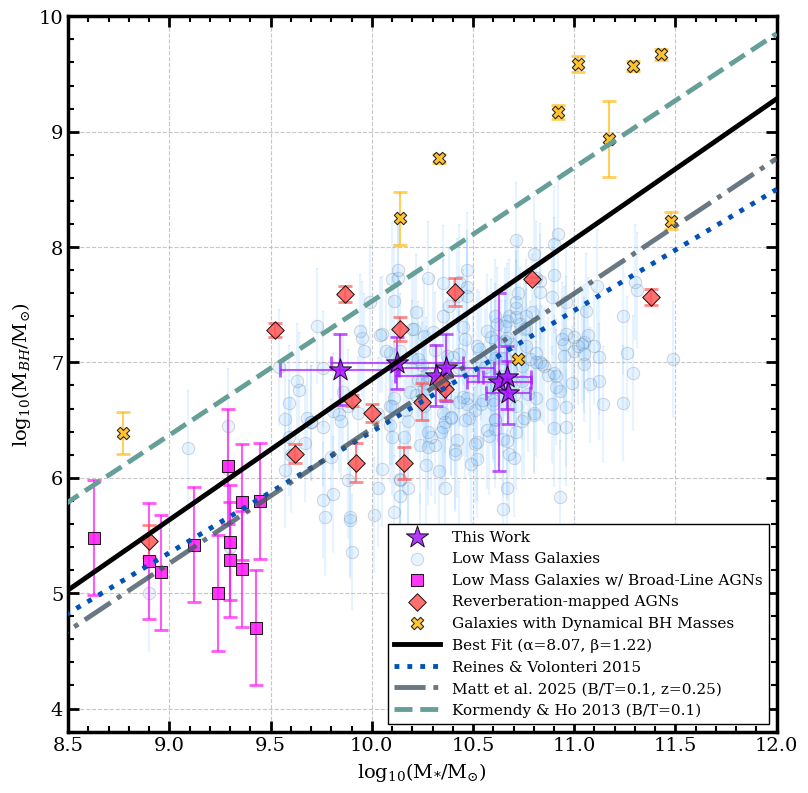

In [18]:
"""
Plotting the Black Hole Mass V Stellar Mass
"""
# ================= Setting up the figure =================
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='white')

# ================= Putting data into arrays =================
Our_Data_Corr_X = [galaxy["Log10_S_M"] for galaxy in Our_Data_Dict.values()]
Our_Data_Corr_Y = [galaxy["Log10_BH_M"] for galaxy in OurData_Corr_Dict.values()]
Our_Data_Corr_X_Err = [galaxy["Log10_S_M_Err"] for galaxy in OurData_Corr_Dict.values()]
Our_Data_Corr_Y_Err = [galaxy["Log10_BH_M_Err"] for galaxy in OurData_Corr_Dict.values()]

Low_Mass_X = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

Reverberation_X = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
Reverberation_Y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
Reverberation_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

Dynamical_X = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

Reines_X = [galaxy["logMs"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y = [galaxy["logMBH"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithAGNBHMasses_Reines]

# ================= Putting together data for our fit =================

# Creating weights and weighting Reines points less in order to balance with the other data sets.
N_Datasets = 5
N_Reines = len(Reines_X)
N_Rest = len(Our_Data_Corr_X) + len(Low_Mass_X) + len(Reverberation_X) + len(Dynamical_X)

Reines_Weight_Factor = N_Rest / (N_Datasets * N_Reines)
Reines_Y_Err_Adjusted = [Err / np.sqrt(Reines_Weight_Factor) for Err in Reines_Y_Err]

#Putting everything together including the weighting
All_X_Values = np.array(Our_Data_Corr_X + Low_Mass_X + Reverberation_X + Dynamical_X + Reines_X)
All_Y_Values = np.array(Our_Data_Corr_Y + Low_Mass_Y + Reverberation_Y + Dynamical_Y + Reines_Y)
All_Y_Err_Values = np.array(Our_Data_Corr_Y_Err + Low_Mass_Y_Err + Reverberation_Y_Err + Dynamical_Y_Err + Reines_Y_Err)

# ================= Calculating the fits for the other data sets =================
X_Values_For_Fits = np.linspace(8.0, 12.0, 100) #Need an array of values that covers the full plot range.

#For Reines
Reines_Fit_Y = power_law_10_11(X_Values_For_Fits, Alpha_Reines, Beta_Reines)

#For Matt
Alpha_Evolved = np.log10((10**Alpha0_Matt) * (1 + 0.25)**Alpha_Z) #z=0.25 because we want it for the local relation
Log_M_Bulge = np.log10(Matt_Bulge_Fraction) + X_Values_For_Fits

Matt_Fit_Y = Alpha_Evolved + Beta0_Matt * (Log_M_Bulge - 11.0)

#For Kormendy & Ho
Kormendy_and_Ho_Fit_Y = Alpha_Kormendy_and_Ho + Beta_Kormendy_and_Ho * (np.log10(1.0) + X_Values_For_Fits - 11)

#For Our Data
try: # Perform fitting with error weights
    # Assuming you have all_y_err as your error array
    popt, pcov = curve_fit(power_law, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    fit_successful = True
except:
    fit_successful = False
    
try: # Add this after your existing curve_fit call
    popt_non_norm, pcov_non_norm = curve_fit(power_law_non_normalized, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit_non_norm, beta_fit_non_norm = popt_non_norm
    alpha_err_non_norm, beta_err_non_norm = np.sqrt(np.diag(pcov_non_norm))
except:
    alpha_fit_non_norm, beta_fit_non_norm = None, None


# ================= Plotting all data points =================
# For our data
ax.scatter(Our_Data_Corr_X, Our_Data_Corr_Y,
          color="#a714ff", edgecolor="black",
           s=280, marker='*', alpha=0.85, linewidths=0.75, zorder=20,
          label='This Work')

ax.errorbar(Our_Data_Corr_X, Our_Data_Corr_Y,
           xerr=Our_Data_Corr_X_Err, yerr=Our_Data_Corr_Y_Err,
           linestyle='', ecolor="#a714ff",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies from Reines 2013
ax.scatter(Reines_X, Reines_Y,
          color="#60B5FF", edgecolor="black", s=80, marker='o', alpha=0.15, linewidths=0.75, zorder=0,
          label='Low Mass Galaxies') # Reines et al. 2013')

ax.errorbar(Reines_X, Reines_Y,
           yerr=Reines_Y_Err, linestyle='', ecolor="#60B5FF",
           capsize=1, capthick=1, alpha=0.15, zorder=0)


# Plot Low mass galaxies
ax.scatter(Low_Mass_X, Low_Mass_Y,
          color="#ff14f5", edgecolor="black", s=80, marker='s', alpha=0.85, linewidths=0.75, zorder=20,
          label='Low Mass Galaxies w/ Broad-Line AGNs')

ax.errorbar(Low_Mass_X, Low_Mass_Y,
           yerr=Low_Mass_Y_Err, linestyle='', ecolor="#ff14f5",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot reverberation-mapped AGNs
ax.scatter(Reverberation_X, Reverberation_Y,
          color="#FF5757", edgecolor="black", s=80, marker='D', alpha=0.85, linewidths=0.75, zorder=20,
          label='Reverberation-mapped AGNs')

ax.errorbar(Reverberation_X, Reverberation_Y,
           yerr=Reverberation_Y_Err, linestyle='', ecolor="#FF5757",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies with dynamical BH masses
ax.scatter(Dynamical_X, Dynamical_Y,
          color=Colors["Orange"], edgecolor="black", s=80, marker='X', alpha=0.85, linewidths=0.75, zorder=20,
          label='Galaxies with Dynamical BH Masses')

ax.errorbar(Dynamical_X, Dynamical_Y,
           yerr=Dynamical_Y_Err, linestyle='', ecolor=Colors["Orange"],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# ================= Plotting all fits =================
if fit_successful:
    Our_Data_Fit_Y = power_law(X_Values_For_Fits, alpha_fit, beta_fit)
    
    ax.plot(X_Values_For_Fits, Our_Data_Fit_Y, 
            color='black', linewidth=3.5, zorder=29,
            label=f'Best Fit (α={alpha_fit:.2f}, β={beta_fit:.2f})')
    
ax.plot(X_Values_For_Fits, Reines_Fit_Y, color='#0052b6', linewidth=3.5, linestyle=":", 
         label='Reines & Volonteri 2015', zorder=28)


ax.plot(X_Values_For_Fits, Matt_Fit_Y, color="#435663", linewidth=3.5, 
        linestyle='-.', alpha=0.8,
        label=f'Matt et al. 2025 (B/T={Matt_Bulge_Fraction}, z=0.25)', zorder=28)

ax.plot(X_Values_For_Fits, Kormendy_and_Ho_Fit_Y, 
             color="#669e98", linewidth=3.5, linestyle="--", 
             label=f'Kormendy & Ho 2013 (B/T={Matt_Bulge_Fraction})', zorder=28)

# ================= Plot Configurations =================
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=14,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=14,
               length=4, width=1.5, direction='in')
ax.tick_params(top=True, right=True)
ax.minorticks_on()

# Legend
legend = ax.legend(loc='lower right', fontsize=11, 
                  frameon=True, fancybox=False, 
                  edgecolor='black', facecolor='white', framealpha=1.0, 
                  ncol=1, columnspacing=0.9, handlelength=3, borderpad=0.4)

# Adjust plot layout
plt.tight_layout(pad=1.0)

ax.set_xlim(8.5, 12.0)
ax.set_ylim(3.8, 10)

# Saving the Figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_Trends_17.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the plot 
plt.show(block=False)


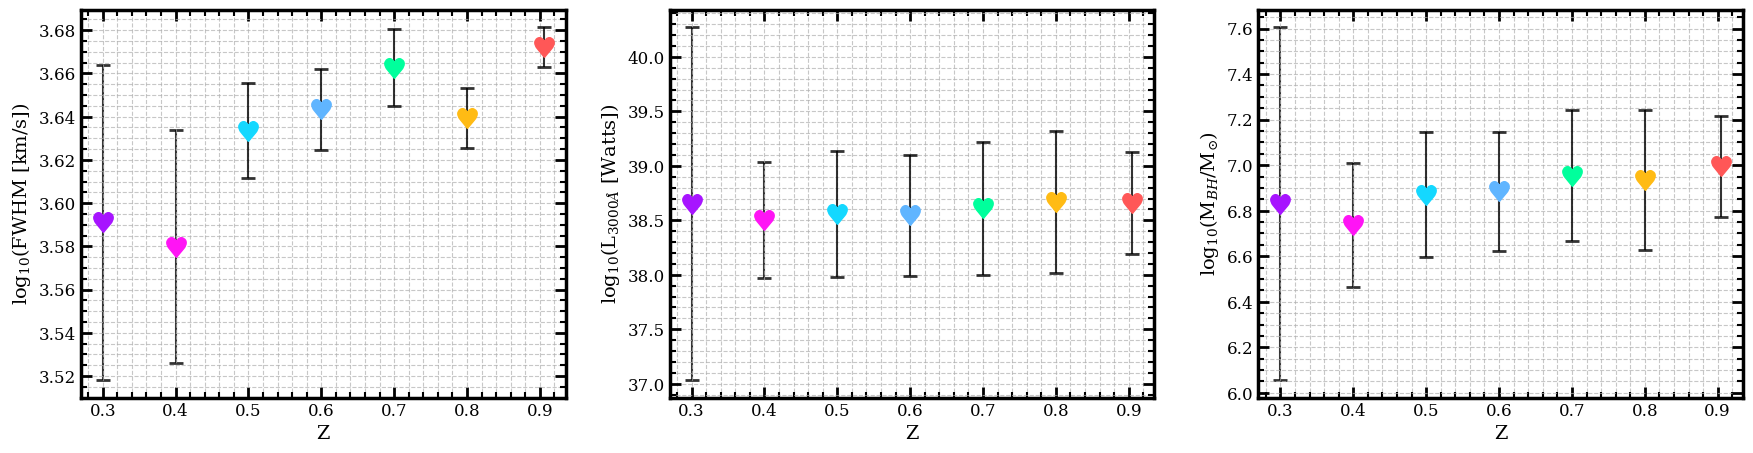

In [19]:
"""
Plotting the three panels FWHM, Luminosity, and Black Hole Mass V Stellar Mass
"""
# ================= Setting up the figure =================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#First Panel
FWHM_Data_Y = np.array([OurData_Corr_Dict[0]["Log10_FWHM"], OurData_Corr_Dict[1]["Log10_FWHM"], 
                        OurData_Corr_Dict[2]["Log10_FWHM"], OurData_Corr_Dict[3]["Log10_FWHM"], 
                        OurData_Corr_Dict[4]["Log10_FWHM"], OurData_Corr_Dict[5]["Log10_FWHM"], OurData_Corr_Dict[6]["Log10_FWHM"]])
FWHM_Data_Y_Err = np.array([OurData_Corr_Dict[0]["Log10_FWHM_Err"], OurData_Corr_Dict[1]["Log10_FWHM_Err"], 
                            OurData_Corr_Dict[2]["Log10_FWHM_Err"], OurData_Corr_Dict[3]["Log10_FWHM_Err"], 
                            OurData_Corr_Dict[4]["Log10_FWHM_Err"], OurData_Corr_Dict[5]["Log10_FWHM_Err"], 
                            OurData_Corr_Dict[6]["Log10_FWHM_Err"]])
#Second Panel
Luminosity_Data_Y = np.array([OurData_Corr_Dict[0]["Log10_Lum"], OurData_Corr_Dict[1]["Log10_Lum"], 
                             OurData_Corr_Dict[2]["Log10_Lum"], OurData_Corr_Dict[3]["Log10_Lum"], 
                             OurData_Corr_Dict[4]["Log10_Lum"], OurData_Corr_Dict[5]["Log10_Lum"], OurData_Corr_Dict[6]["Log10_Lum"]])
Luminosity_Data_Y_Err = np.array([OurData_Corr_Dict[0]["Log10_Lum_Err"], OurData_Corr_Dict[1]["Log10_Lum_Err"], 
                                 OurData_Corr_Dict[2]["Log10_Lum_Err"], OurData_Corr_Dict[3]["Log10_Lum_Err"], 
                                 OurData_Corr_Dict[4]["Log10_Lum_Err"], OurData_Corr_Dict[5]["Log10_Lum_Err"], 
                                 OurData_Corr_Dict[6]["Log10_Lum_Err"]])
#Third Panel
Log10_BH_M_Y = np.array([OurData_Corr_Dict[0]["Log10_BH_M"], OurData_Corr_Dict[1]["Log10_BH_M"], 
                        OurData_Corr_Dict[2]["Log10_BH_M"], OurData_Corr_Dict[3]["Log10_BH_M"], 
                        OurData_Corr_Dict[4]["Log10_BH_M"], OurData_Corr_Dict[5]["Log10_BH_M"], OurData_Corr_Dict[6]["Log10_BH_M"]])
Log10_BH_M_Y_Err = np.array([OurData_Corr_Dict[0]["Log10_BH_M_Err"], OurData_Corr_Dict[1]["Log10_BH_M_Err"], 
                        OurData_Corr_Dict[2]["Log10_BH_M_Err"], OurData_Corr_Dict[3]["Log10_BH_M_Err"], 
                        OurData_Corr_Dict[4]["Log10_BH_M_Err"], OurData_Corr_Dict[5]["Log10_BH_M_Err"], OurData_Corr_Dict[6]["Log10_BH_M_Err"]])

# ================= PANEL 1: FWHM V Redshift =================
#Plotting data
for i in np.arange(7):
    ax1.scatter(Data_X[i], FWHM_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax1.errorbar(Data_X[i], FWHM_Data_Y[i],
                 xerr=None,
                 yerr=FWHM_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

#Plot set up
ax1.set_xlabel(r"Z", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")

ymin1, ymax1 = ax1.get_ylim()

# ================= PANEL 2: Luminosity V Redshift =================
#Plotting data
for i in np.arange(7):
    ax2.scatter(Data_X[i], Luminosity_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax2.errorbar(Data_X[i], Luminosity_Data_Y[i],
                 xerr=None,
                 yerr=Luminosity_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)
    
#Plot set up
ax2.set_xlabel(r"Z", fontsize=14, color="black")
ax2.set_ylabel(r"log$_{10}$(L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")

# ================= PANEL 3: Black Hole Mass V Redshift =================
#Plotting data
for i in np.arange(7):
    ax3.scatter(Data_X[i], Log10_BH_M_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax3.errorbar(Data_X[i], Log10_BH_M_Y[i],
                 xerr=None,
                 yerr=Log10_BH_M_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)
    
#Plot set up
ax3.set_xlabel(r"Z", fontsize=14, color="black")
ax3.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ymin3, ymax3 = ax3.get_ylim()

# ================= Final Plot Set Up =================
for ax in [ax1, ax2, ax3]:
    # Configure grid
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=2.0)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Combined_Three_Panel_Plot_17.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the figure
plt.show(block=False)


/tmp/ipykernel_14997/2776908945.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


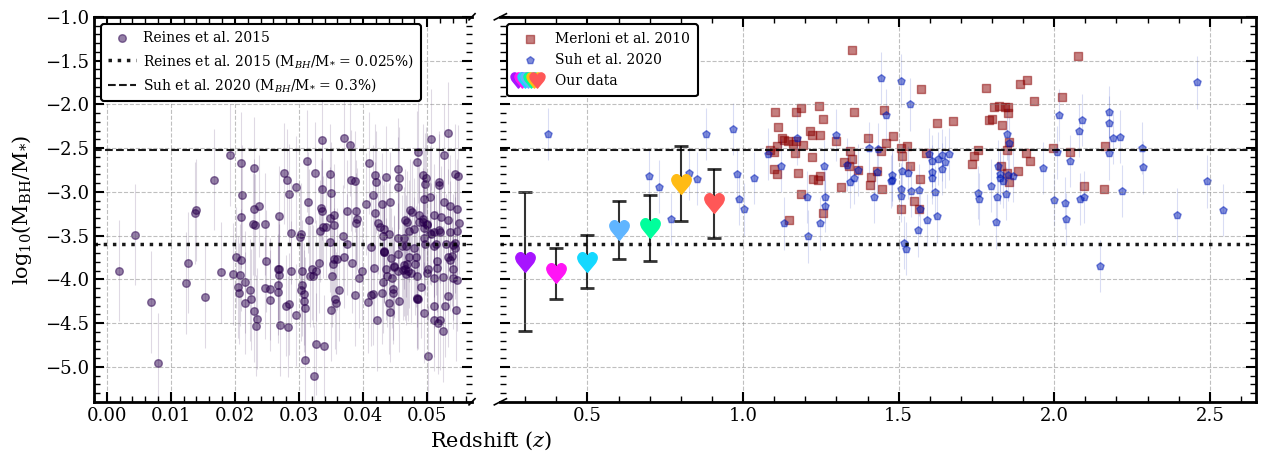

In [20]:
"""
Plotting the Broken Axis Plot of Black Hole Mass / Stellar Mass V Redshift.
"""
# ================= Setting up the figure =================
#Broken axis plot
fig = plt.figure(figsize=(15, 5), facecolor='white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 3], wspace=0.05)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#First Panel
Log10_BH_S_M_Data_Y = np.array([OurData_Corr_Dict[0]["Log10_BH_S_M_Ratio"], OurData_Corr_Dict[1]["Log10_BH_S_M_Ratio"], 
                          OurData_Corr_Dict[2]["Log10_BH_S_M_Ratio"], OurData_Corr_Dict[3]["Log10_BH_S_M_Ratio"], 
                          OurData_Corr_Dict[4]["Log10_BH_S_M_Ratio"], OurData_Corr_Dict[5]["Log10_BH_S_M_Ratio"], 
                          OurData_Corr_Dict[6]["Log10_BH_S_M_Ratio"]])
Log10_BH_S_M_Data_Y_Err = np.array([OurData_Corr_Dict[0]["Log10_BH_S_M_Ratio_Err"], OurData_Corr_Dict[1]["Log10_BH_S_M_Ratio_Err"], 
                              OurData_Corr_Dict[2]["Log10_BH_S_M_Ratio_Err"], OurData_Corr_Dict[3]["Log10_BH_S_M_Ratio_Err"], 
                              OurData_Corr_Dict[4]["Log10_BH_S_M_Ratio_Err"], OurData_Corr_Dict[5]["Log10_BH_S_M_Ratio_Err"], 
                              OurData_Corr_Dict[6]["Log10_BH_S_M_Ratio_Err"]])

# ================= PANEL 1: Reines Data (Local) =================
#Plotting data
ax1.scatter(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
           color="#2A004E", s=30, marker='o', alpha=0.5, zorder=0,
           label='Reines et al. 2015')
ax1.errorbar(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
            yerr=Reines_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#2A004E",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax1.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=15, color="black", labelpad=8)

ax1.set_xlim(-0.002, 0.057)

y_min = -5.4
y_max = -1.0
ax1.set_ylim(y_min, y_max)

ax1.spines['right'].set_visible(False)


# ================= PANEL 2: Our Data, Merloni, and Suh =================
#Plotting data
#Our data
for i in np.arange(7):
    ax2.scatter(Data_X[i], Log10_BH_S_M_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax2.errorbar(Data_X[i], Log10_BH_S_M_Data_Y[i],
                 xerr=None,
                 yerr=Log10_BH_S_M_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

#Merloni
ax2.scatter(Merloni_2010_Redshifts, Merloni_2010_Mbh_Mstellar_Ratio,
           color="#8B0000", s=30, marker='s', alpha=0.5, zorder=0,
           label='Merloni et al. 2010')

#Suh
ax2.scatter(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
           color="#001BB7", s=30, marker='p', alpha=0.5, zorder=0,
           label='Suh et al. 2020')
ax2.errorbar(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
            yerr=Suh_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#001BB7",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

ax2.set_ylim(y_min, y_max)

ax2.set_xlim(0.22, 2.65)

ax2.spines['left'].set_visible(False)



# ================= Across Panels: Reines and Suh values =================
#Plotting data
#Reines (Local)
ax1.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label="Reines et al. 2015 (M$_{BH}$/M$_{*}$ = 0.025%)")

ax2.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000)

#Suh
ax1.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000, label="Suh et al. 2020 (M$_{BH}$/M$_{*}$ = 0.3%)")

ax2.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000)

#Plotting set up for full plot
fig.text(0.39, 0.02, r"Redshift ($z$)", ha='center', fontsize=15, color="black")

for ax in [ax1, ax2]:
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.5, zorder=-10, color='gray')
    ax.minorticks_on()
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    
    ax.tick_params(axis='both', which='major', labelsize=13,
                   length=7, width=1.5, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=11,
                   length=4, width=1.0, direction='in')
    ax.tick_params(top=True, right=True)

# Add diagonal break markers (smaller and cleaner)
d = 0.008
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add legends with better styling
legend1 = ax1.legend(loc='upper left', fontsize=10, frameon=True, 
          edgecolor='black', facecolor='white', framealpha=1.0, 
          borderpad=0.5, handletextpad=0.5, columnspacing=1.0)
legend1.get_frame().set_linewidth(1.5)

# Get current legend handles and labels
handles, labels = ax2.get_legend_handles_labels()

# Add a dummy handle for our gradient heart
gradient_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]
dummy_heart = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=0)
handles.append(dummy_heart)
labels.append('Our data')

# Create legend with custom handler
legend2 = ax2.legend(handles, labels, loc='upper left', fontsize=10, frameon=True,
          edgecolor='black', facecolor='white', framealpha=1.0,
          borderpad=0.6, handletextpad=0.8, columnspacing=1.0,
          handler_map={dummy_heart: HandlerGradientHeart(gradient_colors)})
legend2.get_frame().set_linewidth(1.5)

# Save figure
plt.tight_layout()
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_With_Reines_Z_17.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [21]:
len(np.where( Suh_2020_Redshifts < 0.96)[0])

9

## <font color='#FF76CE' size=5 >Plotting Only the Uncorrected</font>

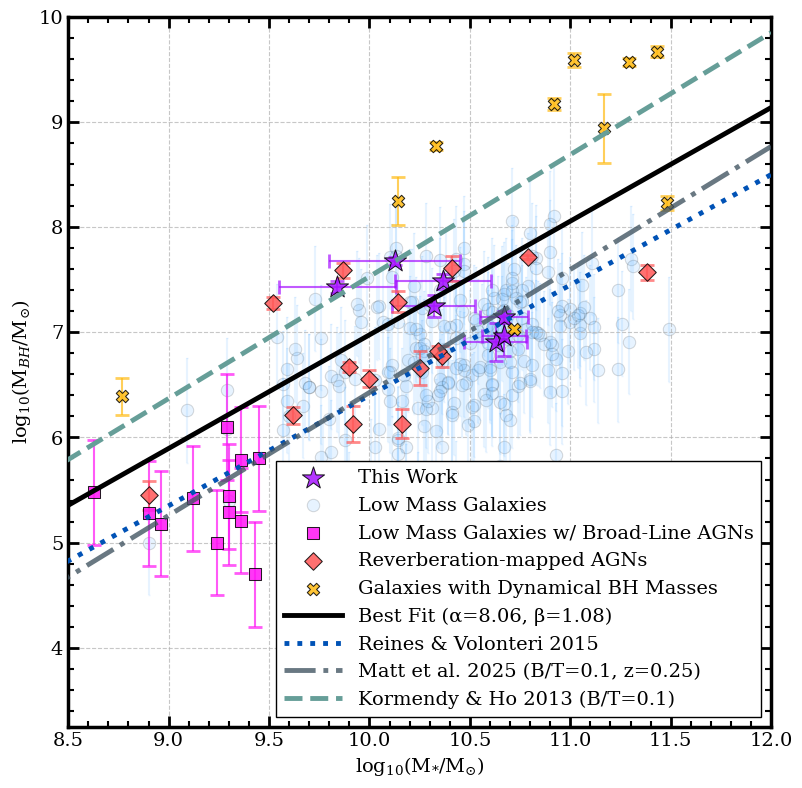

0.011975730860363005 0.018476117157191656

-3.833107532513635 1.08089666295949
0.19559250610319834 0.01847611599375898


In [22]:
"""
Plotting the Black Hole Mass V Stellar Mass
"""

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
})

# ================= Setting up the figure =================
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='white')

# ================= Putting data into arrays =================
Our_Data_X = [galaxy["Log10_S_M"] for galaxy in Our_Data_Dict.values()]
Our_Data_Corr_Y = [galaxy["Log10_BH_M"] for galaxy in Our_Data_Dict.values()]
Our_Data_X_Err = [galaxy["Log10_S_M_Err"] for galaxy in Our_Data_Dict.values()]
Our_Data_Corr_Y_Err = [galaxy["Log10_BH_M_Err"] for galaxy in Our_Data_Dict.values()]

Low_Mass_X = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

Reverberation_X = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
Reverberation_Y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
Reverberation_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

Dynamical_X = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

Reines_X = [galaxy["logMs"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y = [galaxy["logMBH"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithAGNBHMasses_Reines]

# ================= Putting together data for our fit =================

# Creating weights and weighting Reines points less in order to balance with the other data sets.
N_Datasets = 5
N_Reines = len(Reines_X)
N_Rest = len(Our_Data_X) + len(Low_Mass_X) + len(Reverberation_X) + len(Dynamical_X)

Reines_Weight_Factor = N_Rest / (N_Datasets * N_Reines)
Reines_Y_Err_Adjusted = [Err / np.sqrt(Reines_Weight_Factor) for Err in Reines_Y_Err]

#Putting everything together including the weighting
All_X_Values = np.array(Our_Data_X + Low_Mass_X + Reverberation_X + Dynamical_X + Reines_X)
All_Y_Values = np.array(Our_Data_Corr_Y + Low_Mass_Y + Reverberation_Y + Dynamical_Y + Reines_Y)
All_Y_Err_Values = np.array(Our_Data_Corr_Y_Err + Low_Mass_Y_Err + Reverberation_Y_Err + Dynamical_Y_Err + Reines_Y_Err)

# ================= Calculating the fits for the other data sets =================
X_Values_For_Fits = np.linspace(8.0, 12.0, 100) #Need an array of values that covers the full plot range.

#For Reines
Reines_Fit_Y = power_law_10_11(X_Values_For_Fits, Alpha_Reines, Beta_Reines)

#For Matt
Alpha_Evolved = np.log10((10**Alpha0_Matt) * (1 + 0.25)**Alpha_Z) #z=0.25 because we want it for the local relation
Log_M_Bulge = np.log10(Matt_Bulge_Fraction) + X_Values_For_Fits

Matt_Fit_Y = Alpha_Evolved + Beta0_Matt * (Log_M_Bulge - 11.0)

#For Kormendy & Ho
Kormendy_and_Ho_Fit_Y = Alpha_Kormendy_and_Ho + Beta_Kormendy_and_Ho * (np.log10(1.0) + X_Values_For_Fits - 11)

#For Our Data
try: # Perform fitting with error weights
    # Assuming you have all_y_err as your error array
    popt, pcov = curve_fit(power_law, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    fit_successful = True
except:
    fit_successful = False
    
try: # Add this after your existing curve_fit call
    popt_non_norm, pcov_non_norm = curve_fit(power_law_non_normalized, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit_non_norm, beta_fit_non_norm = popt_non_norm
    alpha_err_non_norm, beta_err_non_norm = np.sqrt(np.diag(pcov_non_norm))
except:
    alpha_fit_non_norm, beta_fit_non_norm = None, None


# ================= Plotting all data points =================
# For our data
ax.scatter(Our_Data_X, Our_Data_Corr_Y,
          color="#a714ff", edgecolor="black",
           s=280, marker='*', alpha=0.85, linewidths=0.75, zorder=20,
          label='This Work')

ax.errorbar(Our_Data_X, Our_Data_Corr_Y,
           xerr=Our_Data_X_Err, yerr=Our_Data_Corr_Y_Err,
           linestyle='', ecolor="#a714ff",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies from Reines 2013
ax.scatter(Reines_X, Reines_Y,
          color="#60B5FF", edgecolor="black", s=80, marker='o', alpha=0.15, linewidths=0.75, zorder=0,
          label='Low Mass Galaxies') # Reines et al. 2013')

ax.errorbar(Reines_X, Reines_Y,
           yerr=Reines_Y_Err, linestyle='', ecolor="#60B5FF",
           capsize=1, capthick=1, alpha=0.15, zorder=0)


# Plot Low mass galaxies
ax.scatter(Low_Mass_X, Low_Mass_Y,
          color="#ff14f5", edgecolor="black", s=80, marker='s', alpha=0.85, linewidths=0.75, zorder=20,
          label='Low Mass Galaxies w/ Broad-Line AGNs')

ax.errorbar(Low_Mass_X, Low_Mass_Y,
           yerr=Low_Mass_Y_Err, linestyle='', ecolor="#ff14f5",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot reverberation-mapped AGNs
ax.scatter(Reverberation_X, Reverberation_Y,
          color="#FF5757", edgecolor="black", s=80, marker='D', alpha=0.85, linewidths=0.75, zorder=20,
          label='Reverberation-mapped AGNs')

ax.errorbar(Reverberation_X, Reverberation_Y,
           yerr=Reverberation_Y_Err, linestyle='', ecolor="#FF5757",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies with dynamical BH masses
ax.scatter(Dynamical_X, Dynamical_Y,
          color=Colors["Orange"], edgecolor="black", s=80, marker='X', alpha=0.85, linewidths=0.75, zorder=20,
          label='Galaxies with Dynamical BH Masses')

ax.errorbar(Dynamical_X, Dynamical_Y,
           yerr=Dynamical_Y_Err, linestyle='', ecolor=Colors["Orange"],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# ================= Plotting all fits =================
if fit_successful:
    Our_Data_Fit_Y = power_law(X_Values_For_Fits, alpha_fit, beta_fit)
    
    ax.plot(X_Values_For_Fits, Our_Data_Fit_Y, 
            color='black', linewidth=3.5, zorder=29,
            label=f'Best Fit (α={alpha_fit:.2f}, β={beta_fit:.2f})')
    
ax.plot(X_Values_For_Fits, Reines_Fit_Y, color='#0052b6', linewidth=3.5, linestyle=":", 
         label='Reines & Volonteri 2015', zorder=28)


ax.plot(X_Values_For_Fits, Matt_Fit_Y, color="#435663", linewidth=3.5, 
        linestyle='-.', alpha=0.8,
        label=f'Matt et al. 2025 (B/T={Matt_Bulge_Fraction}, z=0.25)', zorder=28)

ax.plot(X_Values_For_Fits, Kormendy_and_Ho_Fit_Y, 
             color="#669e98", linewidth=3.5, linestyle="--", 
             label=f'Kormendy & Ho 2013 (B/T={Matt_Bulge_Fraction})', zorder=28)

# ================= Plot Configurations =================
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=14,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=14,
               length=4, width=1.5, direction='in')
ax.tick_params(top=True, right=True)
ax.minorticks_on()

# Legend
legend = ax.legend(loc='best',
                  frameon=True, fancybox=False, 
                  edgecolor='black', facecolor='white', framealpha=1.0, 
                  ncol=1, columnspacing=0.9, handlelength=3, borderpad=0.4)

# Adjust plot layout
plt.tight_layout(pad=1.0)

ax.set_xlim(8.5, 12.0)
ax.set_ylim(3.25, 10)

# Saving the Figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_Trends_UnCorrected_17.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the plot 
plt.show(block=False)


# ================= Printing values =================
print(alpha_err, beta_err)
print()
print(alpha_fit_non_norm, beta_fit_non_norm)
print(alpha_err_non_norm, beta_err_non_norm)



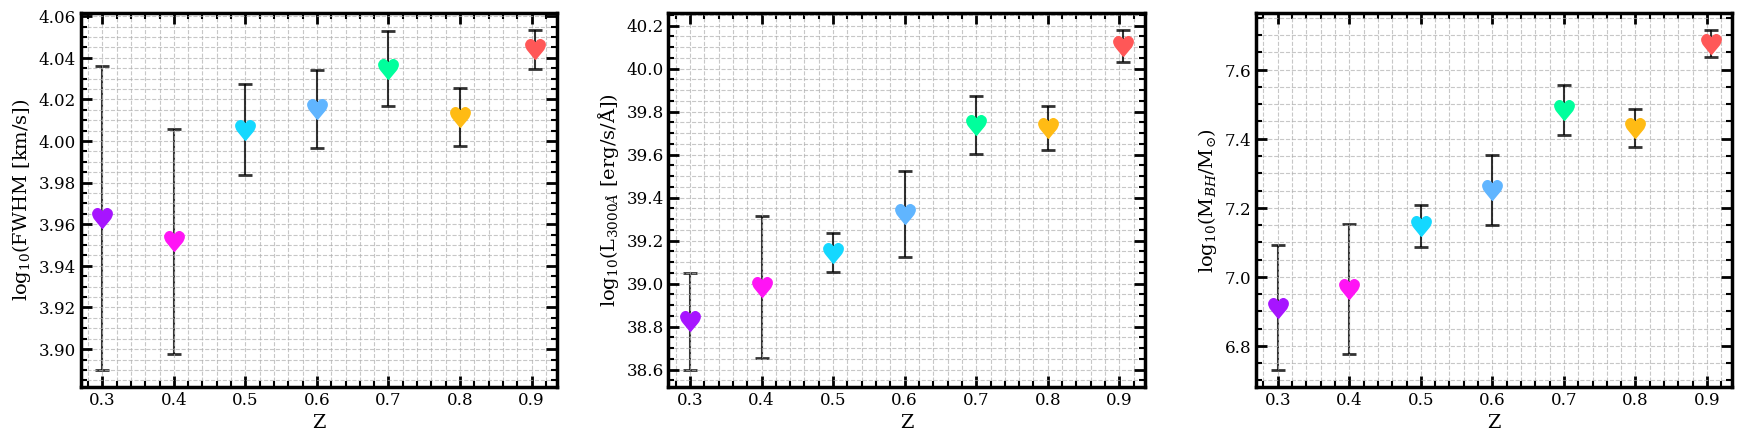

In [23]:
"""
Plotting the three panels FWHM, Luminosity, and Black Hole Mass V Stellar Mass
"""

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
})

# ================= Setting up the figure =================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#First Panel
FWHM_Data_Y = np.array([Our_Data_Dict[0]["Log10_FWHM"], Our_Data_Dict[1]["Log10_FWHM"], 
                        Our_Data_Dict[2]["Log10_FWHM"], Our_Data_Dict[3]["Log10_FWHM"], 
                        Our_Data_Dict[4]["Log10_FWHM"], Our_Data_Dict[5]["Log10_FWHM"], Our_Data_Dict[6]["Log10_FWHM"]])
FWHM_Data_Y_Err = np.array([Our_Data_Dict[0]["Log10_FWHM_Err"], Our_Data_Dict[1]["Log10_FWHM_Err"], 
                            Our_Data_Dict[2]["Log10_FWHM_Err"], Our_Data_Dict[3]["Log10_FWHM_Err"], 
                            Our_Data_Dict[4]["Log10_FWHM_Err"], Our_Data_Dict[5]["Log10_FWHM_Err"], 
                            Our_Data_Dict[6]["Log10_FWHM_Err"]])
#Second Panel
Luminosity_Data_Y = np.array([Our_Data_Dict[0]["Log10_Lum"], Our_Data_Dict[1]["Log10_Lum"], 
                             Our_Data_Dict[2]["Log10_Lum"], Our_Data_Dict[3]["Log10_Lum"], 
                             Our_Data_Dict[4]["Log10_Lum"], Our_Data_Dict[5]["Log10_Lum"], Our_Data_Dict[6]["Log10_Lum"]])
Luminosity_Data_Y_Err = np.array([Our_Data_Dict[0]["Log10_Lum_Err"], Our_Data_Dict[1]["Log10_Lum_Err"], 
                                 Our_Data_Dict[2]["Log10_Lum_Err"], Our_Data_Dict[3]["Log10_Lum_Err"], 
                                 Our_Data_Dict[4]["Log10_Lum_Err"], Our_Data_Dict[5]["Log10_Lum_Err"], 
                                 Our_Data_Dict[6]["Log10_Lum_Err"]])
#Third Panel
Log10_BH_M_Y = np.array([Our_Data_Dict[0]["Log10_BH_M"], Our_Data_Dict[1]["Log10_BH_M"], 
                        Our_Data_Dict[2]["Log10_BH_M"], Our_Data_Dict[3]["Log10_BH_M"], 
                        Our_Data_Dict[4]["Log10_BH_M"], Our_Data_Dict[5]["Log10_BH_M"], Our_Data_Dict[6]["Log10_BH_M"]])
Log10_BH_M_Y_Err = np.array([Our_Data_Dict[0]["Log10_BH_M_Err"], Our_Data_Dict[1]["Log10_BH_M_Err"], 
                        Our_Data_Dict[2]["Log10_BH_M_Err"], Our_Data_Dict[3]["Log10_BH_M_Err"], 
                        Our_Data_Dict[4]["Log10_BH_M_Err"], Our_Data_Dict[5]["Log10_BH_M_Err"], Our_Data_Dict[6]["Log10_BH_M_Err"]])

# ================= PANEL 1: FWHM V Redshift =================
#Plotting data
for i in np.arange(7):
    ax1.scatter(Data_X[i], FWHM_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax1.errorbar(Data_X[i], FWHM_Data_Y[i],
                 xerr=None,
                 yerr=FWHM_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

#Plot set up
ax1.set_xlabel(r"Z", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")

ymin1, ymax1 = ax1.get_ylim()

# ================= PANEL 2: Luminosity V Redshift =================
#Plotting data
for i in np.arange(7):
    ax2.scatter(Data_X[i], Luminosity_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax2.errorbar(Data_X[i], Luminosity_Data_Y[i],
                 xerr=None,
                 yerr=Luminosity_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)
    
#Plot set up
ax2.set_xlabel(r"Z", fontsize=14, color="black")
ax2.set_ylabel(r"log$_{10}$(L$_{3000 \AA}$ [erg/s/$\mathrm{\AA}$])", fontsize=14, color="black")

# ================= PANEL 3: Black Hole Mass V Redshift =================
#Plotting data
for i in np.arange(7):
    ax3.scatter(Data_X[i], Log10_BH_M_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax3.errorbar(Data_X[i], Log10_BH_M_Y[i],
                 xerr=None,
                 yerr=Log10_BH_M_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)
    
#Plot set up
ax3.set_xlabel(r"Z", fontsize=14, color="black")
ax3.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ymin3, ymax3 = ax3.get_ylim()

# ================= Final Plot Set Up =================
for ax in [ax1, ax2, ax3]:
    # Configure grid
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=2.0)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Combined_Three_Panel_UnCorrected_Plot_17.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the figure
plt.show(block=False)


/tmp/ipykernel_14997/1120476056.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


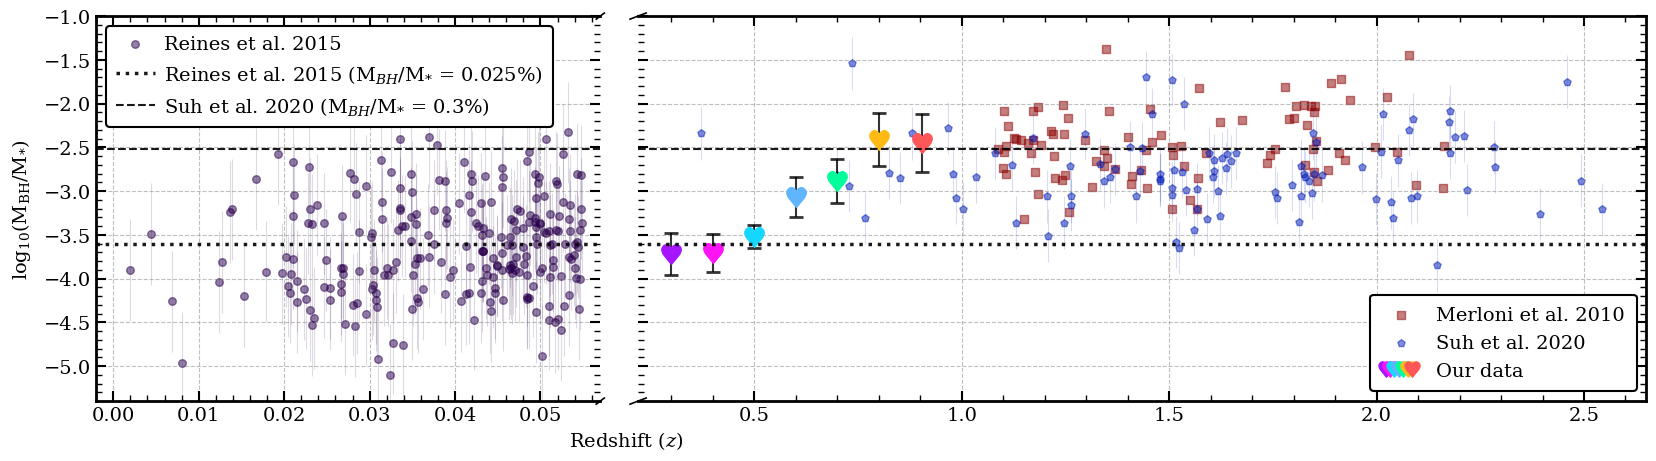


Our Statistics:
Median: -3.0690 ± 0.1790
RMS: 3.1512
Scatter (σ): 0.5173
Fit successful!
log(M_BH/M_*) = -5.016 ± 0.348 + (9.231 ± 1.815) * log10(1+z)


In [24]:
"""
Plotting the Broken Axis Plot of Black Hole Mass / Stellar Mass V Redshift.
"""

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
})

# ================= Setting up the figure =================
#Broken axis plot
fig = plt.figure(figsize=(20, 5), facecolor='white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 3], wspace=0.05)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#First Panel
Log10_BH_S_M_Data_Y = np.array([Our_Data_Dict[0]["Log10_BH_S_M_Ratio"], Our_Data_Dict[1]["Log10_BH_S_M_Ratio"], 
                          Our_Data_Dict[2]["Log10_BH_S_M_Ratio"], Our_Data_Dict[3]["Log10_BH_S_M_Ratio"], 
                          Our_Data_Dict[4]["Log10_BH_S_M_Ratio"], Our_Data_Dict[5]["Log10_BH_S_M_Ratio"], 
                          Our_Data_Dict[6]["Log10_BH_S_M_Ratio"]])
Log10_BH_S_M_Data_Y_Err = np.array([Our_Data_Dict[0]["Log10_BH_S_M_Ratio_Err"], Our_Data_Dict[1]["Log10_BH_S_M_Ratio_Err"], 
                              Our_Data_Dict[2]["Log10_BH_S_M_Ratio_Err"], Our_Data_Dict[3]["Log10_BH_S_M_Ratio_Err"], 
                              Our_Data_Dict[4]["Log10_BH_S_M_Ratio_Err"], Our_Data_Dict[5]["Log10_BH_S_M_Ratio_Err"], 
                              Our_Data_Dict[6]["Log10_BH_S_M_Ratio_Err"]])

# ================= PANEL 1: Reines Data (Local) =================
#Plotting data
ax1.scatter(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
           color="#2A004E", s=30, marker='o', alpha=0.5, zorder=0,
           label='Reines et al. 2015')
ax1.errorbar(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
            yerr=Reines_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#2A004E",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax1.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=14, color="black", labelpad=8)

ax1.set_xlim(-0.002, 0.057)

y_min = -5.4
y_max = -1.0
ax1.set_ylim(y_min, y_max)

ax1.spines['right'].set_visible(False)


# ================= PANEL 2: Our Data, Merloni, and Suh =================
#Plotting data
#Our data
for i in np.arange(7):
    ax2.scatter(Data_X[i], Log10_BH_S_M_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=12)

    ax2.errorbar(Data_X[i], Log10_BH_S_M_Data_Y[i],
                 xerr=None,
                 yerr=Log10_BH_S_M_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=10)

#Merloni
ax2.scatter(Merloni_2010_Redshifts, Merloni_2010_Mbh_Mstellar_Ratio,
           color="#8B0000", s=30, marker='s', alpha=0.5, zorder=0,
           label='Merloni et al. 2010')

#Suh
ax2.scatter(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
           color="#001BB7", s=30, marker='p', alpha=0.5, zorder=0,
           label='Suh et al. 2020')
ax2.errorbar(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
            yerr=Suh_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#001BB7",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

ax2.set_ylim(y_min, y_max)

ax2.set_xlim(0.22, 2.65)

ax2.spines['left'].set_visible(False)



# ================= Across Panels: Reines and Suh values =================
#Plotting data
#Reines (Local)
ax1.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label="Reines et al. 2015 (M$_{BH}$/M$_{*}$ = 0.025%)")

ax2.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000)

#Suh
ax1.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000, label="Suh et al. 2020 (M$_{BH}$/M$_{*}$ = 0.3%)")

ax2.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000)

#Plotting set up for full plot
fig.text(0.39, 0.02, r"Redshift ($z$)", ha='center', fontsize=14, color="black")

for ax in [ax1, ax2]:
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.5, zorder=-10, color='gray')
    ax.minorticks_on()
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    
    ax.tick_params(axis='both', which='major', labelsize=14,
                   length=7, width=1.5, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=14,
                   length=4, width=1.0, direction='in')
    ax.tick_params(top=True, right=True)

# Add diagonal break markers (smaller and cleaner)
d = 0.008
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add legends with better styling
legend1 = ax1.legend(loc='upper left', frameon=True, 
          edgecolor='black', facecolor='white', framealpha=1.0, 
          borderpad=0.5, handletextpad=0.5, columnspacing=1.0)
legend1.get_frame().set_linewidth(1.5)

# Get current legend handles and labels
handles, labels = ax2.get_legend_handles_labels()

# Add a dummy handle for our gradient heart
gradient_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]
dummy_heart = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=0)
handles.append(dummy_heart)
labels.append('Our data')

# Create legend with custom handler
legend2 = ax2.legend(handles, labels, loc='lower right', frameon=True,
          edgecolor='black', facecolor='white', framealpha=1.0,
          borderpad=0.6, handletextpad=0.8, columnspacing=1.0,
          handler_map={dummy_heart: HandlerGradientHeart(gradient_colors)})
legend2.get_frame().set_linewidth(1.5)

# Save figure
plt.tight_layout()
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_With_Reines_Z_UnCorrected_17.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


# Calculate the Median, RMS, and Scatter for our data
Our_Median, Our_Median_Err = median_with_error(Log10_BH_S_M_Data_Y, Log10_BH_S_M_Data_Y_Err)
Our_RMS = np.sqrt(np.mean(Log10_BH_S_M_Data_Y**2))
Our_Scatter = np.std(Log10_BH_S_M_Data_Y)

print(f"\nOur Statistics:")
print(f"Median: {Our_Median:.4f} ± {Our_Median_Err:.4f}")
print(f"RMS: {Our_RMS:.4f}")
print(f"Scatter (σ): {Our_Scatter:.4f}")


# Fitting our data
# Perform fitting
try:
    initial_guess = [-2.5, 0.5]
    popt, pcov = curve_fit(
        power_law_fit, 
        Data_X, 
        Log10_BH_S_M_Data_Y, 
        sigma=Log10_BH_S_M_Data_Y_Err, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    a_fit = popt[0]
    b_fit = popt[1]
    a_fit_err = np.sqrt(np.diag(pcov))[0]
    b_fit_err = np.sqrt(np.diag(pcov))[1]
    fit_successful = True

    print(f"Fit successful!")
    print(f"log(M_BH/M_*) = {a_fit:.3f} ± {a_fit_err:.3f} + ({b_fit:.3f} ± {b_fit_err:.3f}) * log10(1+z)")

except Exception as e:
    fit_successful = False
    print(f"Fit failed: {e}")



In [25]:
print(AGN_Only_Continuums_L3000_median_025_035)
print(AGN_Only_Continuums_L3000_median_035_045)
print(AGN_Only_Continuums_L3000_median_045_055)
print(AGN_Only_Continuums_L3000_median_055_065)
print(AGN_Only_Continuums_L3000_median_065_075)
print(AGN_Only_Continuums_L3000_median_075_085)
print(AGN_Only_Continuums_L3000_median_085_096)

print()


print()
print("BH masses:", [Black_Hole_Masses_Dict[i]["Value"] for i in range(7)])
print("Stellar masses (log10):", [Black_Hole_Stellar_Ratio_Dict[i]["Value"] for i in range(7)])

print()
for i, sm in enumerate([Stellar_Mass_Median_025_035, Stellar_Mass_Median_035_045, 
                         Stellar_Mass_Median_045_055, Stellar_Mass_Median_055_065,
                         Stellar_Mass_Median_065_075, Stellar_Mass_Median_075_085,
                         Stellar_Mass_Median_085_096]):
    print(f"Bin {i}: log10(M*) = {sm:.3f}, M* = {10**sm:.3e}")

6.6673888359043346e+38
9.632101095821485e+38
1.390800717139333e+39
2.103447979775027e+39
5.455594505557331e+39
5.2740808128043115e+39
1.2725225873553165e+40


BH masses: [8152021.621885546, 9200108.919132927, 14000653.502986232, 17805746.18137754, 30458487.476610497, 26931510.324332297, 47344048.354658596]
Stellar masses (log10): [-3.717076896983866, -3.7069694530037434, -3.522344868721782, -3.06897205769391, -2.883456016870016, -2.4106422508956444, -2.449602056306324]

Bin 0: log10(M*) = 10.628, M* = 4.250e+10
Bin 1: log10(M*) = 10.671, M* = 4.686e+10
Bin 2: log10(M*) = 10.668, M* = 4.661e+10
Bin 3: log10(M*) = 10.320, M* = 2.087e+10
Bin 4: log10(M*) = 10.367, M* = 2.329e+10
Bin 5: log10(M*) = 9.841, M* = 6.933e+09
Bin 6: log10(M*) = 10.125, M* = 1.333e+10


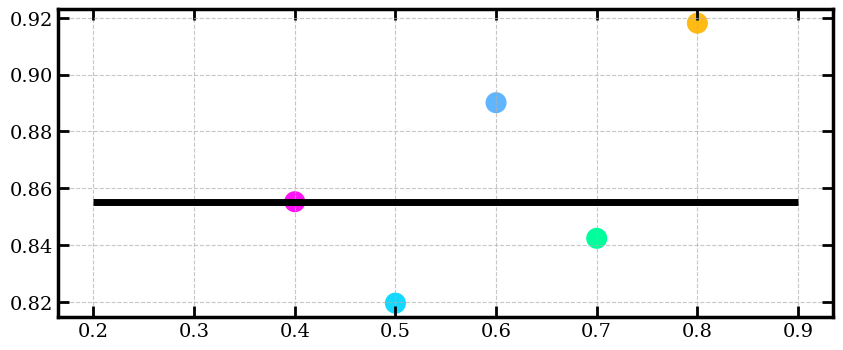

In [26]:
fig = plt.figure(figsize=(10,4))

Data_X = np.array([0.4, 0.5, 0.6, 0.7, 0.8])


plt.scatter(Data_X, R_3000_2000_Array, color = ("#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14"), s = 200)

plt.hlines(y = R_3000_2000_median, xmin = 0.2, xmax = 0.9, linewidth = 5, color = "black")

plt.show()

In [27]:
"""
Printing out the plot values for the paper plots.
"""
print("Luminosities")
print(Our_Data_Dict[0]["Log10_Lum"], Our_Data_Dict[0]["Log10_Lum_Err"])
print(Our_Data_Dict[1]["Log10_Lum"], Our_Data_Dict[1]["Log10_Lum_Err"])
print(Our_Data_Dict[2]["Log10_Lum"], Our_Data_Dict[2]["Log10_Lum_Err"])
print(Our_Data_Dict[3]["Log10_Lum"], Our_Data_Dict[3]["Log10_Lum_Err"])
print(Our_Data_Dict[4]["Log10_Lum"], Our_Data_Dict[4]["Log10_Lum_Err"])
print(Our_Data_Dict[5]["Log10_Lum"], Our_Data_Dict[5]["Log10_Lum_Err"])
print(Our_Data_Dict[6]["Log10_Lum"], Our_Data_Dict[6]["Log10_Lum_Err"])

print()
print()

print("Black hole mass")
print(Our_Data_Dict[0]["Log10_BH_M"], Our_Data_Dict[0]["Log10_BH_M_Err"])
print(Our_Data_Dict[1]["Log10_BH_M"], Our_Data_Dict[1]["Log10_BH_M_Err"])
print(Our_Data_Dict[2]["Log10_BH_M"], Our_Data_Dict[2]["Log10_BH_M_Err"])
print(Our_Data_Dict[3]["Log10_BH_M"], Our_Data_Dict[3]["Log10_BH_M_Err"])
print(Our_Data_Dict[4]["Log10_BH_M"], Our_Data_Dict[4]["Log10_BH_M_Err"])
print(Our_Data_Dict[5]["Log10_BH_M"], Our_Data_Dict[5]["Log10_BH_M_Err"])
print(Our_Data_Dict[6]["Log10_BH_M"], Our_Data_Dict[6]["Log10_BH_M_Err"])

print()
print()

print("Black hole / stellar mass")
print(Our_Data_Dict[0]["Log10_BH_S_M_Ratio"], Our_Data_Dict[0]["Log10_BH_S_M_Ratio_Err"])
print(Our_Data_Dict[1]["Log10_BH_S_M_Ratio"], Our_Data_Dict[1]["Log10_BH_S_M_Ratio_Err"])
print(Our_Data_Dict[2]["Log10_BH_S_M_Ratio"], Our_Data_Dict[2]["Log10_BH_S_M_Ratio_Err"])
print(Our_Data_Dict[3]["Log10_BH_S_M_Ratio"], Our_Data_Dict[3]["Log10_BH_S_M_Ratio_Err"])
print(Our_Data_Dict[4]["Log10_BH_S_M_Ratio"], Our_Data_Dict[4]["Log10_BH_S_M_Ratio_Err"])
print(Our_Data_Dict[5]["Log10_BH_S_M_Ratio"], Our_Data_Dict[5]["Log10_BH_S_M_Ratio_Err"])
print(Our_Data_Dict[6]["Log10_BH_S_M_Ratio"], Our_Data_Dict[6]["Log10_BH_S_M_Ratio_Err"])

print()
print()

print("FWHM")
print(Our_Data_Dict[0]["Log10_FWHM"], Our_Data_Dict[0]["Log10_FWHM_Err"])
print(Our_Data_Dict[1]["Log10_FWHM"], Our_Data_Dict[1]["Log10_FWHM_Err"])
print(Our_Data_Dict[2]["Log10_FWHM"], Our_Data_Dict[2]["Log10_FWHM_Err"])
print(Our_Data_Dict[3]["Log10_FWHM"], Our_Data_Dict[3]["Log10_FWHM_Err"])
print(Our_Data_Dict[4]["Log10_FWHM"], Our_Data_Dict[4]["Log10_FWHM_Err"])
print(Our_Data_Dict[5]["Log10_FWHM"], Our_Data_Dict[5]["Log10_FWHM_Err"])
print(Our_Data_Dict[6]["Log10_FWHM"], Our_Data_Dict[6]["Log10_FWHM_Err"])


print()
print()


print("Other")
print(41.10401612254853 - 39.82359584238863)
print(8.144960184058824 - 7.381096150565233)

Luminosities
38.823955783513654 0.22392491017451197
38.983721032170294 0.3284671146294694
39.14326490594678 0.08994605659576349
39.32293177597935 0.20073041111324466
39.73684208332303 0.13571456466641266
39.722146780043325 0.10192127153891016
40.10466549983136 0.0746594484535922


Black hole mass
6.911265322893994 0.1798181364656893
6.963792968943207 0.18830251112724472
7.146148307543739 0.0608826606339498
7.250560178272248 0.1015198148110444
7.483708333114555 0.07319427112499809
7.430260709413399 0.05550534997626384
7.675265391381755 0.039686551811201065


Black hole / stellar mass
-3.717076896983866 0.2393566723664735
-3.7069694530037434 0.2173324002429252
-3.522344868721782 0.1338588954777951
-3.06897205769391 0.2292200828697134
-2.883456016870016 0.24840179481312447
-2.4106422508956444 0.2983624683606934
-2.449602056306324 0.32884902949452627


FWHM
3.963055518491414 0.07290081221404592
3.9517745080817104 0.053909164641808435
4.005459367044502 0.02190634965434144
4.015443587951102 

## <font color='#FF76CE' size=5 >Plotting both the Uncorrected and corrected</font>

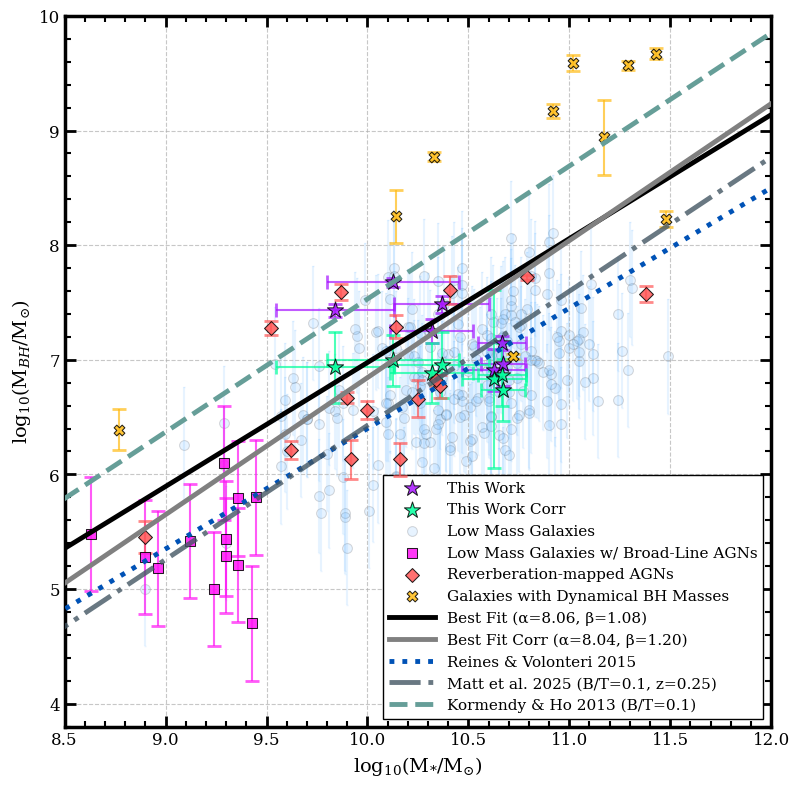

In [28]:
"""
Plotting the Black Hole Mass V Stellar Mass
"""
# ================= Setting up the figure =================
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='white')

# ================= Putting data into arrays =================
Our_Data_X = [galaxy["Log10_S_M"] for galaxy in Our_Data_Dict.values()]
Our_Data_Y = [galaxy["Log10_BH_M"] for galaxy in Our_Data_Dict.values()]
Our_Data_X_Err = [galaxy["Log10_S_M_Err"] for galaxy in Our_Data_Dict.values()]
Our_Data_Y_Err = [galaxy["Log10_BH_M_Err"] for galaxy in Our_Data_Dict.values()]

Our_Data_Corr_X = [galaxy["Log10_S_M"] for galaxy in OurData_Corr_Dict.values()]
Our_Data_Corr_Y = [galaxy["Log10_BH_M"] for galaxy in OurData_Corr_Dict.values()]
Our_Data_Corr_X_Err = [galaxy["Log10_S_M_Err"] for galaxy in OurData_Corr_Dict.values()]
Our_Data_Corr_Y_Err = [galaxy["Log10_BH_M_Err"] for galaxy in OurData_Corr_Dict.values()]

Low_Mass_X = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

Reverberation_X = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
Reverberation_Y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
Reverberation_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

Dynamical_X = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

Reines_X = [galaxy["logMs"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y = [galaxy["logMBH"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithAGNBHMasses_Reines]

# ================= Putting together data for our fit =================
All_X_Values = np.array(Our_Data_X + Low_Mass_X + Reverberation_X + Dynamical_X + Reines_X)
All_Corr_X_Values = np.array(Our_Data_Corr_X + Low_Mass_X + Reverberation_X + Dynamical_X + Reines_X)

All_Y_Values = np.array(Our_Data_Y + Low_Mass_Y + Reverberation_Y + Dynamical_Y + Reines_Y)
All_Y_Err_Values = np.array(Our_Data_Y_Err + Low_Mass_Y_Err + Reverberation_Y_Err + Dynamical_Y_Err + Reines_Y_Err)
All_Corr_Y_Values = np.array(Our_Data_Corr_Y + Low_Mass_Y + Reverberation_Y + Dynamical_Y + Reines_Y)
All_Corr_Y_Err_Values = np.array(Our_Data_Corr_Y_Err + Low_Mass_Y_Err + Reverberation_Y_Err + Dynamical_Y_Err + Reines_Y_Err)

# ================= Calculating the fits for the other data sets =================
X_Values_For_Fits = np.linspace(8.0, 12.0, 100) #Need an array of values that covers the full plot range.

#For Reines
Reines_Fit_Y = power_law_10_11(X_Values_For_Fits, Alpha_Reines, Beta_Reines)

#For Matt
Alpha_Evolved = np.log10((10**Alpha0_Matt) * (1 + 0.25)**Alpha_Z) #z=0.25 because we want it for the local relation
Log_M_Bulge = np.log10(Matt_Bulge_Fraction) + X_Values_For_Fits

Matt_Fit_Y = Alpha_Evolved + Beta0_Matt * (Log_M_Bulge - 11.0)

#For Kormendy & Ho
Kormendy_and_Ho_Fit_Y = Alpha_Kormendy_and_Ho + Beta_Kormendy_and_Ho * (np.log10(1.0) + X_Values_For_Fits - 11)

#For our data uncorrected
try: # Perform fitting with error weights
    # Assuming you have all_y_err as your error array
    popt, pcov = curve_fit(power_law, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    fit_successful = True
except:
    fit_successful = False
    
try: # Add this after your existing curve_fit call
    popt_non_norm, pcov_non_norm = curve_fit(power_law_non_normalized, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit_non_norm, beta_fit_non_norm = popt_non_norm
    alpha_err_non_norm, beta_err_non_norm = np.sqrt(np.diag(pcov_non_norm))
except:
    alpha_fit_non_norm, beta_fit_non_norm = None, None

#For our data corrected
try: # Perform fitting with error weights
    # Assuming you have all_y_err as your error array
    popt_corr, pcov_corr = curve_fit(power_law, All_Corr_X_Values, All_Corr_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit_corr, beta_fit_corr = popt_corr
    alpha_err_corr, beta_err_corr = np.sqrt(np.diag(pcov_corr))
    fit_successful_corr = True
except:
    fit_successful_corr = False
    
try: # Add this after your existing curve_fit call
    popt_non_norm_corr, pcov_non_norm_corr = curve_fit(power_law_non_normalized, All_Corr_X_Values, All_Corr_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit_non_norm_corr, beta_fit_non_norm_corr = popt_non_norm_corr
    alpha_err_non_norm_corr, beta_err_non_norm_corr = np.sqrt(np.diag(pcov_non_norm_corr))
except:
    alpha_fit_non_norm_corr, beta_fit_non_norm_corr = None, None

# ================= Plotting all data points =================
# For our data uncorrected
ax.scatter(Our_Data_X, Our_Data_Y,
          color="#a714ff", edgecolor="black",
           s=150, marker='*', alpha=0.85, linewidths=0.75, zorder=20,
          label='This Work')

ax.errorbar(Our_Data_X, Our_Data_Y,
           xerr=Our_Data_X_Err, yerr=Our_Data_Y_Err,
           linestyle='', ecolor="#a714ff",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# For our data corrected
ax.scatter(Our_Data_Corr_X, Our_Data_Corr_Y,
          color=Colors["Green"], edgecolor="black",
           s=150, marker='*', alpha=0.85, linewidths=0.75, zorder=20,
          label='This Work Corr')

ax.errorbar(Our_Data_Corr_X, Our_Data_Corr_Y,
           xerr=Our_Data_Corr_X_Err, yerr=Our_Data_Corr_Y_Err,
           linestyle='', ecolor=Colors["Green"],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies from Reines 2013
ax.scatter(Reines_X, Reines_Y,
          color="#60B5FF", edgecolor="black", s=50, marker='o', alpha=0.15, linewidths=0.75, zorder=0,
          label='Low Mass Galaxies') # Reines et al. 2013')

ax.errorbar(Reines_X, Reines_Y,
           yerr=Reines_Y_Err, linestyle='', ecolor="#60B5FF",
           capsize=1, capthick=1, alpha=0.15, zorder=0)


# Plot Low mass galaxies
ax.scatter(Low_Mass_X, Low_Mass_Y,
          color="#ff14f5", edgecolor="black", s=50, marker='s', alpha=0.85, linewidths=0.75, zorder=20,
          label='Low Mass Galaxies w/ Broad-Line AGNs')

ax.errorbar(Low_Mass_X, Low_Mass_Y,
           yerr=Low_Mass_Y_Err, linestyle='', ecolor="#ff14f5",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot reverberation-mapped AGNs
ax.scatter(Reverberation_X, Reverberation_Y,
          color="#FF5757", edgecolor="black", s=50, marker='D', alpha=0.85, linewidths=0.75, zorder=20,
          label='Reverberation-mapped AGNs')

ax.errorbar(Reverberation_X, Reverberation_Y,
           yerr=Reverberation_Y_Err, linestyle='', ecolor="#FF5757",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies with dynamical BH masses
ax.scatter(Dynamical_X, Dynamical_Y,
          color=Colors["Orange"], edgecolor="black", s=60, marker='X', alpha=0.85, linewidths=0.75, zorder=20,
          label='Galaxies with Dynamical BH Masses')

ax.errorbar(Dynamical_X, Dynamical_Y,
           yerr=Dynamical_Y_Err, linestyle='', ecolor=Colors["Orange"],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# ================= Plotting all fits =================
if fit_successful:
    Our_Data_Fit_Y = power_law(X_Values_For_Fits, alpha_fit, beta_fit)
    
    ax.plot(X_Values_For_Fits, Our_Data_Fit_Y, 
            color='black', linewidth=3.5, zorder=29,
            label=f'Best Fit (α={alpha_fit:.2f}, β={beta_fit:.2f})')

if fit_successful_corr:
    Our_Data_Fit_Y = power_law(X_Values_For_Fits, alpha_fit_corr, beta_fit_corr)
    
    ax.plot(X_Values_For_Fits, Our_Data_Fit_Y, 
            color='grey', linewidth=3.5, zorder=29,
            label=f'Best Fit Corr (α={alpha_fit_corr:.2f}, β={beta_fit_corr:.2f})')
    
ax.plot(X_Values_For_Fits, Reines_Fit_Y, color='#0052b6', linewidth=3.5, linestyle=":", 
         label='Reines & Volonteri 2015', zorder=28)


ax.plot(X_Values_For_Fits, Matt_Fit_Y, color="#435663", linewidth=3.5, 
        linestyle='-.', alpha=0.8,
        label=f'Matt et al. 2025 (B/T={Matt_Bulge_Fraction}, z=0.25)', zorder=28)

ax.plot(X_Values_For_Fits, Kormendy_and_Ho_Fit_Y, 
             color="#669e98", linewidth=3.5, linestyle="--", 
             label=f'Kormendy & Ho 2013 (B/T={Matt_Bulge_Fraction})', zorder=28)

# ================= Plot Configurations =================
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')
ax.tick_params(top=True, right=True)
ax.minorticks_on()

# Legend
legend = ax.legend(loc='lower right', fontsize=11, 
                  frameon=True, fancybox=False, 
                  edgecolor='black', facecolor='white', framealpha=1.0, 
                  ncol=1, columnspacing=0.9, handlelength=3, borderpad=0.4)

# Adjust plot layout
plt.tight_layout(pad=1.0)

ax.set_xlim(8.5, 12.0)
ax.set_ylim(3.8, 10)

# Saving the Figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_Trends_UnCorrected_And_Corrected_17.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the plot 
plt.show(block=False)


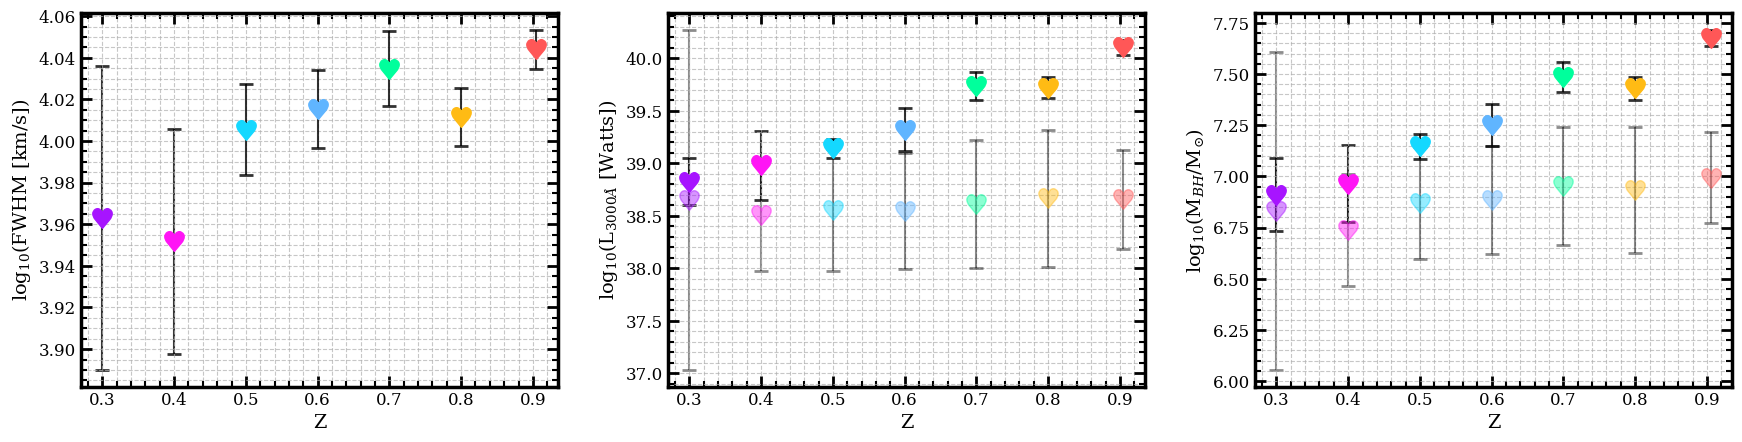

In [29]:
"""
Plotting the three panels FWHM, Luminosity, and Black Hole Mass V Stellar Mass
"""
# ================= Setting up the figure =================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#First Panel
FWHM_Data_Y = np.array([Our_Data_Dict[0]["Log10_FWHM"], Our_Data_Dict[1]["Log10_FWHM"], 
                        Our_Data_Dict[2]["Log10_FWHM"], Our_Data_Dict[3]["Log10_FWHM"], 
                        Our_Data_Dict[4]["Log10_FWHM"], Our_Data_Dict[5]["Log10_FWHM"], Our_Data_Dict[6]["Log10_FWHM"]])
FWHM_Data_Y_Err = np.array([Our_Data_Dict[0]["Log10_FWHM_Err"], Our_Data_Dict[1]["Log10_FWHM_Err"], 
                            Our_Data_Dict[2]["Log10_FWHM_Err"], Our_Data_Dict[3]["Log10_FWHM_Err"], 
                            Our_Data_Dict[4]["Log10_FWHM_Err"], Our_Data_Dict[5]["Log10_FWHM_Err"], 
                            Our_Data_Dict[6]["Log10_FWHM_Err"]])
#Second Panel
Luminosity_Data_Y = np.array([Our_Data_Dict[0]["Log10_Lum"], Our_Data_Dict[1]["Log10_Lum"], 
                             Our_Data_Dict[2]["Log10_Lum"], Our_Data_Dict[3]["Log10_Lum"], 
                             Our_Data_Dict[4]["Log10_Lum"], Our_Data_Dict[5]["Log10_Lum"], Our_Data_Dict[6]["Log10_Lum"]])
Luminosity_Data_Y_Err = np.array([Our_Data_Dict[0]["Log10_Lum_Err"], Our_Data_Dict[1]["Log10_Lum_Err"], 
                                 Our_Data_Dict[2]["Log10_Lum_Err"], Our_Data_Dict[3]["Log10_Lum_Err"], 
                                 Our_Data_Dict[4]["Log10_Lum_Err"], Our_Data_Dict[5]["Log10_Lum_Err"], 
                                 Our_Data_Dict[6]["Log10_Lum_Err"]])

Luminosity_Corr_Data_Y = np.array([OurData_Corr_Dict[0]["Log10_Lum"], OurData_Corr_Dict[1]["Log10_Lum"], 
                             OurData_Corr_Dict[2]["Log10_Lum"], OurData_Corr_Dict[3]["Log10_Lum"], 
                             OurData_Corr_Dict[4]["Log10_Lum"], OurData_Corr_Dict[5]["Log10_Lum"], OurData_Corr_Dict[6]["Log10_Lum"]])
Luminosity_Corr_Data_Y_Err = np.array([OurData_Corr_Dict[0]["Log10_Lum_Err"], OurData_Corr_Dict[1]["Log10_Lum_Err"], 
                                 OurData_Corr_Dict[2]["Log10_Lum_Err"], OurData_Corr_Dict[3]["Log10_Lum_Err"], 
                                 OurData_Corr_Dict[4]["Log10_Lum_Err"], OurData_Corr_Dict[5]["Log10_Lum_Err"], 
                                 OurData_Corr_Dict[6]["Log10_Lum_Err"]])
#Third Panel
Log10_BH_M_Y = np.array([Our_Data_Dict[0]["Log10_BH_M"], Our_Data_Dict[1]["Log10_BH_M"], 
                        Our_Data_Dict[2]["Log10_BH_M"], Our_Data_Dict[3]["Log10_BH_M"], 
                        Our_Data_Dict[4]["Log10_BH_M"], Our_Data_Dict[5]["Log10_BH_M"], Our_Data_Dict[6]["Log10_BH_M"]])
Log10_BH_M_Y_Err = np.array([Our_Data_Dict[0]["Log10_BH_M_Err"], Our_Data_Dict[1]["Log10_BH_M_Err"], 
                        Our_Data_Dict[2]["Log10_BH_M_Err"], Our_Data_Dict[3]["Log10_BH_M_Err"], 
                        Our_Data_Dict[4]["Log10_BH_M_Err"], Our_Data_Dict[5]["Log10_BH_M_Err"], Our_Data_Dict[6]["Log10_BH_M_Err"]])

Log10_BH_M_Corr_Y = np.array([OurData_Corr_Dict[0]["Log10_BH_M"], OurData_Corr_Dict[1]["Log10_BH_M"], 
                        OurData_Corr_Dict[2]["Log10_BH_M"], OurData_Corr_Dict[3]["Log10_BH_M"], 
                        OurData_Corr_Dict[4]["Log10_BH_M"], OurData_Corr_Dict[5]["Log10_BH_M"], OurData_Corr_Dict[6]["Log10_BH_M"]])
Log10_BH_M_Corr_Y_Err = np.array([OurData_Corr_Dict[0]["Log10_BH_M_Err"], OurData_Corr_Dict[1]["Log10_BH_M_Err"], 
                        OurData_Corr_Dict[2]["Log10_BH_M_Err"], OurData_Corr_Dict[3]["Log10_BH_M_Err"], 
                        OurData_Corr_Dict[4]["Log10_BH_M_Err"], OurData_Corr_Dict[5]["Log10_BH_M_Err"], OurData_Corr_Dict[6]["Log10_BH_M_Err"]])

# ================= PANEL 1: FWHM V Redshift =================
#Plotting data
for i in np.arange(7):
    ax1.scatter(Data_X[i], FWHM_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax1.errorbar(Data_X[i], FWHM_Data_Y[i],
                 xerr=None,
                 yerr=FWHM_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

#Plot set up
ax1.set_xlabel(r"Z", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")

ymin1, ymax1 = ax1.get_ylim()

# ================= PANEL 2: Luminosity V Redshift =================
#Plotting data uncorrected
for i in np.arange(7):
    ax2.scatter(Data_X[i], Luminosity_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax2.errorbar(Data_X[i], Luminosity_Data_Y[i],
                 xerr=None,
                 yerr=Luminosity_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

#Plotting data corrected
for i in np.arange(7):
    ax2.scatter(Data_X[i], Luminosity_Corr_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=0.45,
                zorder=10+i)

    ax2.errorbar(Data_X[i], Luminosity_Corr_Data_Y[i],
                 xerr=None,
                 yerr=Luminosity_Corr_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.45,
                 zorder=i)
    
#Plot set up
ax2.set_xlabel(r"Z", fontsize=14, color="black")
ax2.set_ylabel(r"log$_{10}$(L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")

# ================= PANEL 3: Black Hole Mass V Redshift =================
#Plotting data uncorrected
for i in np.arange(7):
    ax3.scatter(Data_X[i], Log10_BH_M_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax3.errorbar(Data_X[i], Log10_BH_M_Y[i],
                 xerr=None,
                 yerr=Log10_BH_M_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

#Plotting data corrected
for i in np.arange(7):
    ax3.scatter(Data_X[i], Log10_BH_M_Corr_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=0.45,
                zorder=10+i)

    ax3.errorbar(Data_X[i], Log10_BH_M_Corr_Y[i],
                 xerr=None,
                 yerr=Log10_BH_M_Corr_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.45,
                 zorder=i)
    
#Plot set up
ax3.set_xlabel(r"Z", fontsize=14, color="black")
ax3.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ymin3, ymax3 = ax3.get_ylim()

# ================= Final Plot Set Up =================
for ax in [ax1, ax2, ax3]:
    # Configure grid
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=2.0)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Combined_Three_Panel_UnCorrected_And_Corrected_Plot_17.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the figure
plt.show(block=False)


/tmp/ipykernel_14997/1079382569.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


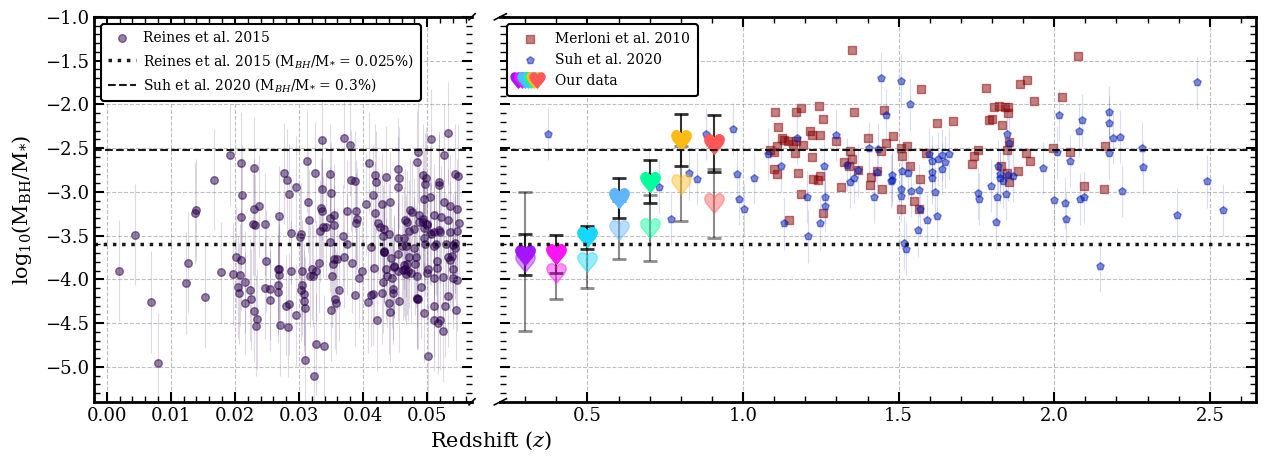

In [30]:
"""
Plotting the Broken Axis Plot of Black Hole Mass / Stellar Mass V Redshift.
"""
# ================= Setting up the figure =================
#Broken axis plot
fig = plt.figure(figsize=(15, 5), facecolor='white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 3], wspace=0.05)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#Second Panel uncorrected
Log10_BH_S_M_Data_Y = np.array([Our_Data_Dict[0]["Log10_BH_S_M_Ratio"], Our_Data_Dict[1]["Log10_BH_S_M_Ratio"], 
                          Our_Data_Dict[2]["Log10_BH_S_M_Ratio"], Our_Data_Dict[3]["Log10_BH_S_M_Ratio"], 
                          Our_Data_Dict[4]["Log10_BH_S_M_Ratio"], Our_Data_Dict[5]["Log10_BH_S_M_Ratio"], 
                          Our_Data_Dict[6]["Log10_BH_S_M_Ratio"]])
Log10_BH_S_M_Data_Y_Err = np.array([Our_Data_Dict[0]["Log10_BH_S_M_Ratio_Err"], Our_Data_Dict[1]["Log10_BH_S_M_Ratio_Err"], 
                              Our_Data_Dict[2]["Log10_BH_S_M_Ratio_Err"], Our_Data_Dict[3]["Log10_BH_S_M_Ratio_Err"], 
                              Our_Data_Dict[4]["Log10_BH_S_M_Ratio_Err"], Our_Data_Dict[5]["Log10_BH_S_M_Ratio_Err"], 
                              Our_Data_Dict[6]["Log10_BH_S_M_Ratio_Err"]])
#Second Panel corrected
Log10_BH_S_M_Corr_Data_Y = np.array([OurData_Corr_Dict[0]["Log10_BH_S_M_Ratio"], OurData_Corr_Dict[1]["Log10_BH_S_M_Ratio"], 
                          OurData_Corr_Dict[2]["Log10_BH_S_M_Ratio"], OurData_Corr_Dict[3]["Log10_BH_S_M_Ratio"], 
                          OurData_Corr_Dict[4]["Log10_BH_S_M_Ratio"], OurData_Corr_Dict[5]["Log10_BH_S_M_Ratio"], 
                          OurData_Corr_Dict[6]["Log10_BH_S_M_Ratio"]])
Log10_BH_S_M_Corr_Data_Y_Err = np.array([OurData_Corr_Dict[0]["Log10_BH_S_M_Ratio_Err"], OurData_Corr_Dict[1]["Log10_BH_S_M_Ratio_Err"], 
                              OurData_Corr_Dict[2]["Log10_BH_S_M_Ratio_Err"], OurData_Corr_Dict[3]["Log10_BH_S_M_Ratio_Err"], 
                              OurData_Corr_Dict[4]["Log10_BH_S_M_Ratio_Err"], OurData_Corr_Dict[5]["Log10_BH_S_M_Ratio_Err"], 
                              OurData_Corr_Dict[6]["Log10_BH_S_M_Ratio_Err"]])

# ================= PANEL 1: Reines Data (Local) =================
#Plotting data
ax1.scatter(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
           color="#2A004E", s=30, marker='o', alpha=0.5, zorder=0,
           label='Reines et al. 2015')
ax1.errorbar(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
            yerr=Reines_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#2A004E",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax1.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=15, color="black", labelpad=8)

ax1.set_xlim(-0.002, 0.057)

y_min = -5.4
y_max = -1.0
ax1.set_ylim(y_min, y_max)

ax1.spines['right'].set_visible(False)


# ================= PANEL 2: Our Data Uncorrected and Corrected, Merloni, and Suh =================
#Plotting data
#Our data uncorrected
for i in np.arange(7):
    ax2.scatter(Data_X[i], Log10_BH_S_M_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=12)

    ax2.errorbar(Data_X[i], Log10_BH_S_M_Data_Y[i],
                 xerr=None,
                 yerr=Log10_BH_S_M_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=10)
    
#Our data corrected
for i in np.arange(7):
    ax2.scatter(Data_X[i], Log10_BH_S_M_Corr_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=0.45,
                zorder=11)

    ax2.errorbar(Data_X[i], Log10_BH_S_M_Corr_Data_Y[i],
                 xerr=None,
                 yerr=Log10_BH_S_M_Corr_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.45,
                 zorder=9)

#Merloni
ax2.scatter(Merloni_2010_Redshifts, Merloni_2010_Mbh_Mstellar_Ratio,
           color="#8B0000", s=30, marker='s', alpha=0.5, zorder=0,
           label='Merloni et al. 2010')

#Suh
ax2.scatter(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
           color="#001BB7", s=30, marker='p', alpha=0.5, zorder=0,
           label='Suh et al. 2020')
ax2.errorbar(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
            yerr=Suh_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#001BB7",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

ax2.set_ylim(y_min, y_max)

ax2.set_xlim(0.22, 2.65)

ax2.spines['left'].set_visible(False)



# ================= Across Panels: Reines and Suh values =================
#Plotting data
#Reines (Local)
ax1.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label="Reines et al. 2015 (M$_{BH}$/M$_{*}$ = 0.025%)")

ax2.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000)

#Suh
ax1.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000, label="Suh et al. 2020 (M$_{BH}$/M$_{*}$ = 0.3%)")

ax2.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000)

#Plotting set up for full plot
fig.text(0.39, 0.02, r"Redshift ($z$)", ha='center', fontsize=15, color="black")

for ax in [ax1, ax2]:
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.5, zorder=-10, color='gray')
    ax.minorticks_on()
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    
    ax.tick_params(axis='both', which='major', labelsize=13,
                   length=7, width=1.5, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=11,
                   length=4, width=1.0, direction='in')
    ax.tick_params(top=True, right=True)

# Add diagonal break markers (smaller and cleaner)
d = 0.008
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add legends with better styling
legend1 = ax1.legend(loc='upper left', fontsize=10, frameon=True, 
          edgecolor='black', facecolor='white', framealpha=1.0, 
          borderpad=0.5, handletextpad=0.5, columnspacing=1.0)
legend1.get_frame().set_linewidth(1.5)

# Get current legend handles and labels
handles, labels = ax2.get_legend_handles_labels()

# Add a dummy handle for our gradient heart
gradient_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]
dummy_heart = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=0)
handles.append(dummy_heart)
labels.append('Our data')

# Create legend with custom handler
legend2 = ax2.legend(handles, labels, loc='upper left', fontsize=10, frameon=True,
          edgecolor='black', facecolor='white', framealpha=1.0,
          borderpad=0.6, handletextpad=0.8, columnspacing=1.0,
          handler_map={dummy_heart: HandlerGradientHeart(gradient_colors)})
legend2.get_frame().set_linewidth(1.5)

# Save figure
plt.tight_layout()
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_With_Reines_Z_UnCorrected_And_Corrected_17.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [31]:
print(10**-2.9634 * 100)
print(((10**(-2.9634 + 0.1512)) *100)) 
print(((10**(-2.9634 - 0.1512)) *100))
print(0.15409906371070778-0.07680685809900982)
# -2.9634 ± 0.1512

0.10879276133832898
0.15409906371070778
0.07680685809900982
0.07729220561169796


In [32]:
np.log10(0.003)

-2.5228787452803374

## <font color='#FF76CE' size=5 >Plotting Only the Uncorrected With FeII Removed</font>

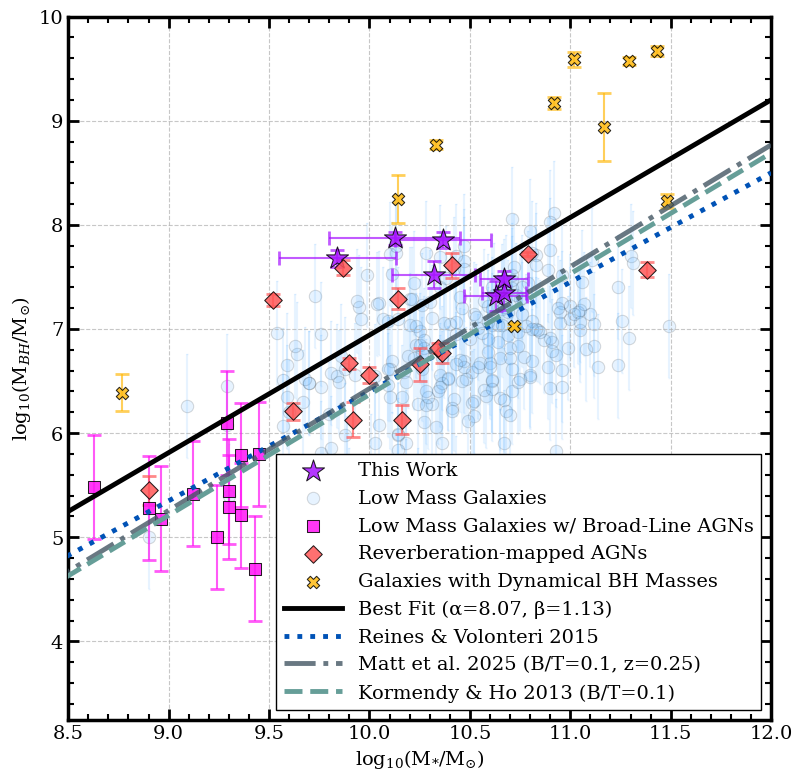

Normalized
____________
Alpha = 8.070864277787246 +- 0.012011738691190679
Beta = 1.1291696303267111 +- 0.019105595286933032

Not Normalized
_________________
Alpha = -4.350002035986176 +- 0.20278380356151418
Beta = 1.1291696651193224 +- 0.019105594783612036


In [44]:
"""
Plotting the Black Hole Mass V Stellar Mass
"""

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
})                           

# ================= Setting up the figure =================
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='white')

# ================= Putting data into arrays =================
Our_Data_X = [galaxy["Log10_S_M"] for galaxy in Our_Data_FeII_Removed_Dict.values()]
Our_Data_Corr_Y = [galaxy["Log10_BH_M_FeII_Removed"] for galaxy in Our_Data_FeII_Removed_Dict.values()]
Our_Data_X_Err = [galaxy["Log10_S_M_Err"] for galaxy in Our_Data_FeII_Removed_Dict.values()]
Our_Data_Corr_Y_Err = [galaxy["Log10_BH_M_FeII_Removed_Err"] for galaxy in Our_Data_FeII_Removed_Dict.values()]

Low_Mass_X = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
Low_Mass_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

Reverberation_X = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
Reverberation_Y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
Reverberation_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

Dynamical_X = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
Dynamical_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

Reines_X = [galaxy["logMs"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y = [galaxy["logMBH"] for galaxy in galaxiesWithAGNBHMasses_Reines]
Reines_Y_Err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithAGNBHMasses_Reines]

# ================= Putting together data for our fit =================

# Creating weights and weighting Reines points less in order to balance with the other data sets.
N_Datasets = 5
N_Reines = len(Reines_X)
N_Rest = len(Our_Data_X) + len(Low_Mass_X) + len(Reverberation_X) + len(Dynamical_X)

Reines_Weight_Factor = N_Rest / (N_Datasets * N_Reines)
Reines_Y_Err_Adjusted = [Err / np.sqrt(Reines_Weight_Factor) for Err in Reines_Y_Err]

#Putting everything together including the weighting
All_X_Values = np.array(Our_Data_X + Low_Mass_X + Reverberation_X + Dynamical_X + Reines_X)
All_Y_Values = np.array(Our_Data_Corr_Y + Low_Mass_Y + Reverberation_Y + Dynamical_Y + Reines_Y)
All_Y_Err_Values = np.array(Our_Data_Corr_Y_Err + Low_Mass_Y_Err + Reverberation_Y_Err + Dynamical_Y_Err + Reines_Y_Err)

# ================= Calculating the fits for the other data sets =================
X_Values_For_Fits = np.linspace(8.0, 12.0, 100) #Need an array of values that covers the full plot range.

#For Reines
Reines_Fit_Y = power_law_10_11(X_Values_For_Fits, Alpha_Reines, Beta_Reines)

#For Matt
Alpha_Evolved = np.log10((10**Alpha0_Matt) * (1 + 0.25)**Alpha_Z) #z=0.25 because we want it for the local relation
Log_M_Bulge = np.log10(Matt_Bulge_Fraction) + X_Values_For_Fits

Matt_Fit_Y = Alpha_Evolved + Beta0_Matt * (Log_M_Bulge - 11.0)

#For Kormendy & Ho
Log_M_Bulge_KH = np.log10(Matt_Bulge_Fraction) + X_Values_For_Fits
Kormendy_and_Ho_Fit_Y = Alpha_Kormendy_and_Ho + Beta_Kormendy_and_Ho * (Log_M_Bulge_KH - 11)

#For Our Data
try: # Perform fitting with error weights
    # Assuming you have all_y_err as your error array
    popt, pcov = curve_fit(power_law, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    fit_successful = True
except:
    fit_successful = False
    
try: # Add this after your existing curve_fit call
    popt_non_norm, pcov_non_norm = curve_fit(power_law_non_normalized, All_X_Values, All_Y_Values, sigma=All_Y_Err_Values, absolute_sigma=True)
    alpha_fit_non_norm, beta_fit_non_norm = popt_non_norm
    alpha_err_non_norm, beta_err_non_norm = np.sqrt(np.diag(pcov_non_norm))
except:
    alpha_fit_non_norm, beta_fit_non_norm = None, None


# ================= Plotting all data points =================
# For our data
ax.scatter(Our_Data_X, Our_Data_Corr_Y,
          color="#a714ff", edgecolor="black",
           s=280, marker='*', alpha=0.85, linewidths=0.75, zorder=20,
          label='This Work')

ax.errorbar(Our_Data_X, Our_Data_Corr_Y,
           xerr=Our_Data_X_Err, yerr=Our_Data_Corr_Y_Err,
           linestyle='', ecolor="#a714ff",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies from Reines 2013
ax.scatter(Reines_X, Reines_Y,
          color="#60B5FF", edgecolor="black", s=80, marker='o', alpha=0.15, linewidths=0.75, zorder=0,
          label='Low Mass Galaxies') # Reines et al. 2013')

ax.errorbar(Reines_X, Reines_Y,
           yerr=Reines_Y_Err, linestyle='', ecolor="#60B5FF",
           capsize=1, capthick=1, alpha=0.15, zorder=0)


# Plot Low mass galaxies
ax.scatter(Low_Mass_X, Low_Mass_Y,
          color="#ff14f5", edgecolor="black", s=80, marker='s', alpha=0.85, linewidths=0.75, zorder=20,
          label='Low Mass Galaxies w/ Broad-Line AGNs')

ax.errorbar(Low_Mass_X, Low_Mass_Y,
           yerr=Low_Mass_Y_Err, linestyle='', ecolor="#ff14f5",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot reverberation-mapped AGNs
ax.scatter(Reverberation_X, Reverberation_Y,
          color="#FF5757", edgecolor="black", s=80, marker='D', alpha=0.85, linewidths=0.75, zorder=20,
          label='Reverberation-mapped AGNs')

ax.errorbar(Reverberation_X, Reverberation_Y,
           yerr=Reverberation_Y_Err, linestyle='', ecolor="#FF5757",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot galaxies with dynamical BH masses
ax.scatter(Dynamical_X, Dynamical_Y,
          color=Colors["Orange"], edgecolor="black", s=80, marker='X', alpha=0.85, linewidths=0.75, zorder=20,
          label='Galaxies with Dynamical BH Masses')

ax.errorbar(Dynamical_X, Dynamical_Y,
           yerr=Dynamical_Y_Err, linestyle='', ecolor=Colors["Orange"],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# ================= Plotting all fits =================
if fit_successful:
    Our_Data_Fit_Y = power_law(X_Values_For_Fits, alpha_fit, beta_fit)
    
    ax.plot(X_Values_For_Fits, Our_Data_Fit_Y, 
            color='black', linewidth=3.5, zorder=29,
            label=f'Best Fit (α={alpha_fit:.2f}, β={beta_fit:.2f})')
    
ax.plot(X_Values_For_Fits, Reines_Fit_Y, color='#0052b6', linewidth=3.5, linestyle=":", 
         label='Reines & Volonteri 2015', zorder=28)


ax.plot(X_Values_For_Fits, Matt_Fit_Y, color="#435663", linewidth=3.5, 
        linestyle='-.', alpha=0.8,
        label=f'Matt et al. 2025 (B/T={Matt_Bulge_Fraction}, z=0.25)', zorder=28)

ax.plot(X_Values_For_Fits, Kormendy_and_Ho_Fit_Y, 
             color="#669e98", linewidth=3.5, linestyle="--", 
             label=f'Kormendy & Ho 2013 (B/T={Matt_Bulge_Fraction})', zorder=28)

# ================= Plot Configurations =================
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=14,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=14,
               length=4, width=1.5, direction='in')
ax.tick_params(top=True, right=True)
ax.minorticks_on()

# Legend
legend = ax.legend(loc='best',
                  frameon=True, fancybox=False, 
                  edgecolor='black', facecolor='white', framealpha=1.0, 
                  ncol=1, columnspacing=0.9, handlelength=3, borderpad=0.4)

# Adjust plot layout
plt.tight_layout(pad=1.0)

ax.set_xlim(8.5, 12.0)
ax.set_ylim(3.25, 10)

# Saving the Figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_Trends_UnCorrected_17_FeII_Removed.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the plot 
plt.show(block=False)


# ================= Printing values =================
print("Normalized")
print("____________")
print(f"Alpha = {alpha_fit} +- {alpha_err}")
print(f"Beta = {beta_fit} +- {beta_err}")
print()
print("Not Normalized")
print("_________________")
print(f"Alpha = {alpha_fit_non_norm} +- {alpha_err_non_norm}")
print(f"Beta = {beta_fit_non_norm} +- {beta_err_non_norm}")




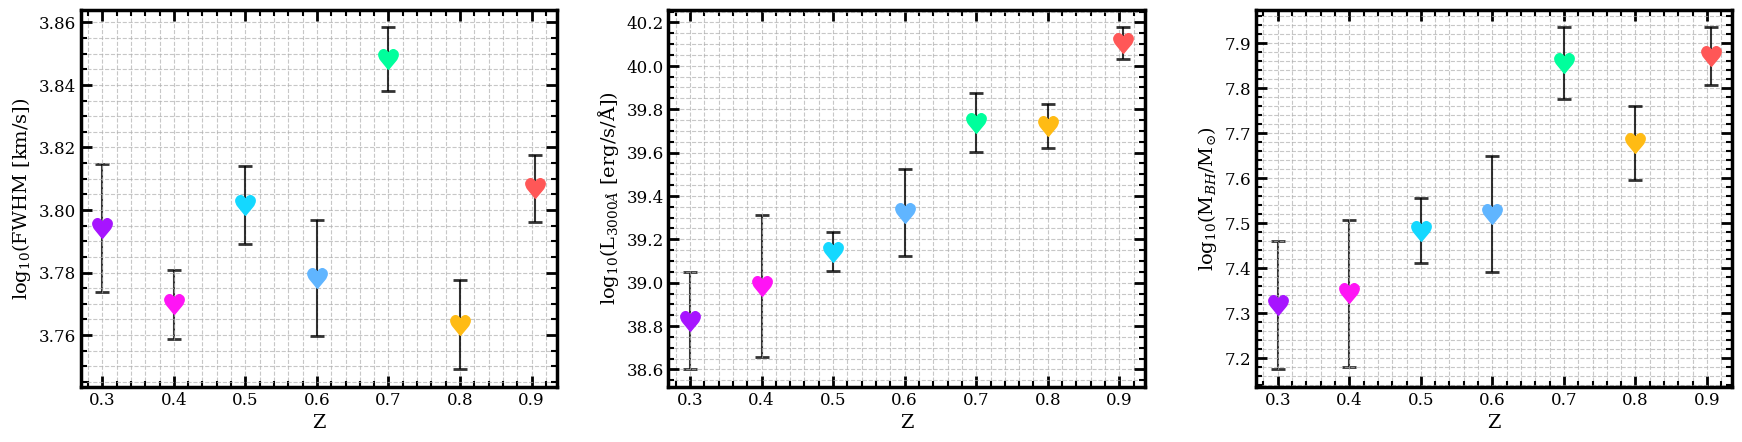

In [34]:
"""
Plotting the three panels FWHM, Luminosity, and Black Hole Mass V Stellar Mass
"""

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
})


# ================= Setting up the figure =================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#First Panel
FWHM_Data_FeII_Removed_260_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[1]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[2]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[3]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[4]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[5]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[6]["Log10_FWHM_260"]])

FWHM_Data_FeII_Removed_260_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[1]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[2]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[3]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[4]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[5]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[6]["Log10_FWHM_260_Err"]])
#Second Panel
Luminosity_Data_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[1]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[2]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[3]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[4]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[5]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[6]["Log10_Lum"]])

Luminosity_Data_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[1]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[2]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[3]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[4]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[5]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[6]["Log10_Lum_Err"]])
#Third Panel
Log10_BH_M_FeII_Removed_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[1]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[2]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[3]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[4]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[5]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[6]["Log10_BH_M_FeII_Removed"]])

Log10_BH_M_FeII_Removed_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[1]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[2]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[3]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[4]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[5]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[6]["Log10_BH_M_FeII_Removed_Err"]])

# ================= PANEL 1: FWHM V Redshift =================
#Plotting data
for i in np.arange(7):
    ax1.scatter(Data_X[i], FWHM_Data_FeII_Removed_260_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax1.errorbar(Data_X[i], FWHM_Data_FeII_Removed_260_Y[i],
                 xerr=None,
                 yerr=FWHM_Data_FeII_Removed_260_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

#Plot set up
ax1.set_xlabel(r"Z", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")

ymin1, ymax1 = ax1.get_ylim()

# ================= PANEL 2: Luminosity V Redshift =================
#Plotting data
for i in np.arange(7):
    ax2.scatter(Data_X[i], Luminosity_Data_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax2.errorbar(Data_X[i], Luminosity_Data_Y[i],
                 xerr=None,
                 yerr=Luminosity_Data_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)
    
#Plot set up
ax2.set_xlabel(r"Z", fontsize=14, color="black")
ax2.set_ylabel(r"log$_{10}$(L$_{3000 \AA}$ [erg/s/$\mathrm{\AA}$])", fontsize=14, color="black")

# ================= PANEL 3: Black Hole Mass V Redshift =================
#Plotting data
for i in np.arange(7):
    ax3.scatter(Data_X[i], Log10_BH_M_FeII_Removed_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i)

    ax3.errorbar(Data_X[i], Log10_BH_M_FeII_Removed_Y[i],
                 xerr=None,
                 yerr=Log10_BH_M_FeII_Removed_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)
    
#Plot set up
ax3.set_xlabel(r"Z", fontsize=14, color="black")
ax3.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

ymin3, ymax3 = ax3.get_ylim()

# ================= Final Plot Set Up =================
for ax in [ax1, ax2, ax3]:
    # Configure grid
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=2.0)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Combined_Three_Panel_UnCorrected_Plot_17_FeII_Removed.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the figure
plt.show(block=False)


/tmp/ipykernel_14997/3428180933.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


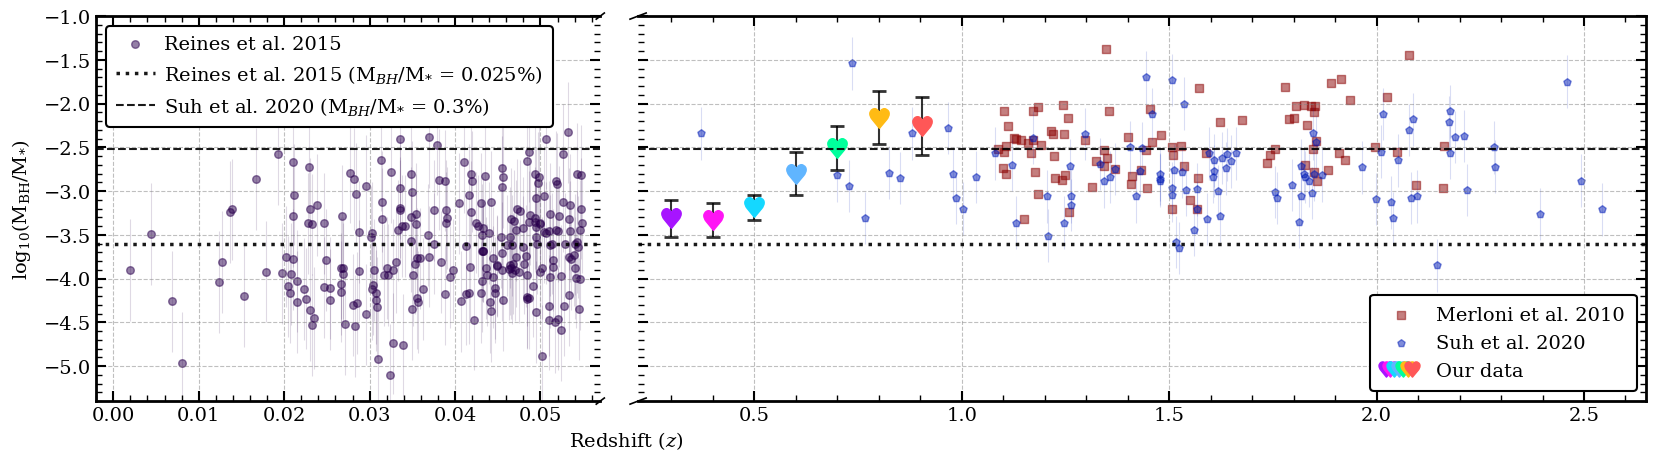


Our Statistics:
Median: -2.7994 ± 0.1823
RMS: 2.8306
Scatter (σ): 0.4588
Fit successful!
log(M_BH/M_*) = -4.436 ± 0.329 + (7.938 ± 1.747) * log10(1+z)


In [35]:
"""
Plotting the Broken Axis Plot of Black Hole Mass / Stellar Mass V Redshift.
"""

import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
})

# ================= Setting up the figure =================
#Broken axis plot
fig = plt.figure(figsize=(20, 5), facecolor='white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 3], wspace=0.05)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ================= Setting up the data sets =================
Data_X = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

#First Panel
Log10_BH_S_M_Data_FeII_Removed_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_S_M_Ratio_FeII_Removed"], Our_Data_FeII_Removed_Dict[1]["Log10_BH_S_M_Ratio_FeII_Removed"], 
                          Our_Data_FeII_Removed_Dict[2]["Log10_BH_S_M_Ratio_FeII_Removed"], Our_Data_FeII_Removed_Dict[3]["Log10_BH_S_M_Ratio_FeII_Removed"], 
                          Our_Data_FeII_Removed_Dict[4]["Log10_BH_S_M_Ratio_FeII_Removed"], Our_Data_FeII_Removed_Dict[5]["Log10_BH_S_M_Ratio_FeII_Removed"], 
                          Our_Data_FeII_Removed_Dict[6]["Log10_BH_S_M_Ratio_FeII_Removed"]])

Log10_BH_S_M_Data_FeII_Removed_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], Our_Data_FeII_Removed_Dict[1]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], 
                              Our_Data_FeII_Removed_Dict[2]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], Our_Data_FeII_Removed_Dict[3]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], 
                              Our_Data_FeII_Removed_Dict[4]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], Our_Data_FeII_Removed_Dict[5]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], 
                              Our_Data_FeII_Removed_Dict[6]["Log10_BH_S_M_Ratio_FeII_Removed_Err"]])

# ================= PANEL 1: Reines Data (Local) =================
#Plotting data
ax1.scatter(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
           color="#2A004E", s=30, marker='o', alpha=0.5, zorder=0,
           label='Reines et al. 2015')
ax1.errorbar(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
            yerr=Reines_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#2A004E",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax1.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=14, color="black", labelpad=8)

ax1.set_xlim(-0.002, 0.057)

y_min = -5.4
y_max = -1.0
ax1.set_ylim(y_min, y_max)

ax1.spines['right'].set_visible(False)


# ================= PANEL 2: Our Data, Merloni, and Suh =================
#Plotting data
#Our data
for i in np.arange(7):
    ax2.scatter(Data_X[i], Log10_BH_S_M_Data_FeII_Removed_Y[i],
                color=Colors_List[i],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=12)

    ax2.errorbar(Data_X[i], Log10_BH_S_M_Data_FeII_Removed_Y[i],
                 xerr=None,
                 yerr=Log10_BH_S_M_Data_FeII_Removed_Y_Err[i],
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=10)

#Merloni
ax2.scatter(Merloni_2010_Redshifts, Merloni_2010_Mbh_Mstellar_Ratio,
           color="#8B0000", s=30, marker='s', alpha=0.5, zorder=0,
           label='Merloni et al. 2010')

#Suh
ax2.scatter(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
           color="#001BB7", s=30, marker='p', alpha=0.5, zorder=0,
           label='Suh et al. 2020')
ax2.errorbar(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
            yerr=Suh_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#001BB7",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

#Plot set up
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

ax2.set_ylim(y_min, y_max)

ax2.set_xlim(0.22, 2.65)

ax2.spines['left'].set_visible(False)



# ================= Across Panels: Reines and Suh values =================
#Plotting data
#Reines (Local)
ax1.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label="Reines et al. 2015 (M$_{BH}$/M$_{*}$ = 0.025%)")

ax2.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000)

#Suh
ax1.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000, label="Suh et al. 2020 (M$_{BH}$/M$_{*}$ = 0.3%)")

ax2.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000)

#Plotting set up for full plot
fig.text(0.39, 0.02, r"Redshift ($z$)", ha='center', fontsize=14, color="black")

for ax in [ax1, ax2]:
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.5, zorder=-10, color='gray')
    ax.minorticks_on()
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    
    ax.tick_params(axis='both', which='major', labelsize=14,
                   length=7, width=1.5, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=14,
                   length=4, width=1.0, direction='in')
    ax.tick_params(top=True, right=True)

# Add diagonal break markers (smaller and cleaner)
d = 0.008
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add legends with better styling
legend1 = ax1.legend(loc='upper left', frameon=True, 
          edgecolor='black', facecolor='white', framealpha=1.0, 
          borderpad=0.5, handletextpad=0.5, columnspacing=1.0)
legend1.get_frame().set_linewidth(1.5)

# Get current legend handles and labels
handles, labels = ax2.get_legend_handles_labels()

# Add a dummy handle for our gradient heart
gradient_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]
dummy_heart = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=0)
handles.append(dummy_heart)
labels.append('Our data')

# Create legend with custom handler
legend2 = ax2.legend(handles, labels, loc='lower right', frameon=True,
          edgecolor='black', facecolor='white', framealpha=1.0,
          borderpad=0.6, handletextpad=0.8, columnspacing=1.0,
          handler_map={dummy_heart: HandlerGradientHeart(gradient_colors)})
legend2.get_frame().set_linewidth(1.5)

# Save figure
plt.tight_layout()
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_With_Reines_Z_UnCorrected_17_FeII_Removed.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


# Calculate the Median, RMS, and Scatter for our data
Our_Median, Our_Median_Err = median_with_error(Log10_BH_S_M_Data_FeII_Removed_Y, Log10_BH_S_M_Data_FeII_Removed_Y_Err)
Our_RMS = np.sqrt(np.mean(Log10_BH_S_M_Data_FeII_Removed_Y**2))
Our_Scatter = np.std(Log10_BH_S_M_Data_FeII_Removed_Y)

print(f"\nOur Statistics:")
print(f"Median: {Our_Median:.4f} ± {Our_Median_Err:.4f}")
print(f"RMS: {Our_RMS:.4f}")
print(f"Scatter (σ): {Our_Scatter:.4f}")


# Fitting our data
# Perform fitting
try:
    initial_guess = [-2.5, 0.5]
    popt, pcov = curve_fit(
        power_law_fit, 
        Data_X, 
        Log10_BH_S_M_Data_FeII_Removed_Y, 
        sigma=Log10_BH_S_M_Data_FeII_Removed_Y_Err, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    a_fit = popt[0]
    b_fit = popt[1]
    a_fit_err = np.sqrt(np.diag(pcov))[0]
    b_fit_err = np.sqrt(np.diag(pcov))[1]
    fit_successful = True

    print(f"Fit successful!")
    print(f"log(M_BH/M_*) = {a_fit:.3f} ± {a_fit_err:.3f} + ({b_fit:.3f} ± {b_fit_err:.3f}) * log10(1+z)")

except Exception as e:
    fit_successful = False
    print(f"Fit failed: {e}")



In [36]:
Log10_BH_S_M_Data_FeII_Removed_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_S_M_Ratio_FeII_Removed"], Our_Data_FeII_Removed_Dict[1]["Log10_BH_S_M_Ratio_FeII_Removed"], 
                          Our_Data_FeII_Removed_Dict[2]["Log10_BH_S_M_Ratio_FeII_Removed"], Our_Data_FeII_Removed_Dict[3]["Log10_BH_S_M_Ratio_FeII_Removed"], 
                          Our_Data_FeII_Removed_Dict[4]["Log10_BH_S_M_Ratio_FeII_Removed"], Our_Data_FeII_Removed_Dict[5]["Log10_BH_S_M_Ratio_FeII_Removed"], 
                          Our_Data_FeII_Removed_Dict[6]["Log10_BH_S_M_Ratio_FeII_Removed"]])

Log10_BH_S_M_Data_FeII_Removed_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], Our_Data_FeII_Removed_Dict[1]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], 
                              Our_Data_FeII_Removed_Dict[2]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], Our_Data_FeII_Removed_Dict[3]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], 
                              Our_Data_FeII_Removed_Dict[4]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], Our_Data_FeII_Removed_Dict[5]["Log10_BH_S_M_Ratio_FeII_Removed_Err"], 
                              Our_Data_FeII_Removed_Dict[6]["Log10_BH_S_M_Ratio_FeII_Removed_Err"]])



FWHM_Data_FeII_Removed_260_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[1]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[2]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[3]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[4]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[5]["Log10_FWHM_260"], 
                                                        Our_Data_FeII_Removed_Dict[6]["Log10_FWHM_260"]])

FWHM_Data_FeII_Removed_260_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[1]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[2]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[3]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[4]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[5]["Log10_FWHM_260_Err"], 
                                                            Our_Data_FeII_Removed_Dict[6]["Log10_FWHM_260_Err"]])
#Second Panel
Luminosity_Data_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[1]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[2]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[3]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[4]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[5]["Log10_Lum"], 
                              Our_Data_FeII_Removed_Dict[6]["Log10_Lum"]])

Luminosity_Data_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[1]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[2]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[3]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[4]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[5]["Log10_Lum_Err"], 
                                  Our_Data_FeII_Removed_Dict[6]["Log10_Lum_Err"]])
#Third Panel
Log10_BH_M_FeII_Removed_Y = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[1]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[2]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[3]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[4]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[5]["Log10_BH_M_FeII_Removed"], 
                                      Our_Data_FeII_Removed_Dict[6]["Log10_BH_M_FeII_Removed"]])

Log10_BH_M_FeII_Removed_Y_Err = np.array([Our_Data_FeII_Removed_Dict[0]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[1]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[2]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[3]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[4]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[5]["Log10_BH_M_FeII_Removed_Err"], 
                                          Our_Data_FeII_Removed_Dict[6]["Log10_BH_M_FeII_Removed_Err"]])



Our_Data_X = [galaxy["Log10_S_M"] for galaxy in Our_Data_FeII_Removed_Dict.values()]
Our_Data_Corr_Y = [galaxy["Log10_BH_M_FeII_Removed"] for galaxy in Our_Data_FeII_Removed_Dict.values()]
Our_Data_X_Err = [galaxy["Log10_S_M_Err"] for galaxy in Our_Data_FeII_Removed_Dict.values()]
Our_Data_Corr_Y_Err = [galaxy["Log10_BH_M_FeII_Removed_Err"] for galaxy in Our_Data_FeII_Removed_Dict.values()]



6.6673888359043346e+38
9.632101095821485e+38
1.390800717139333e+39
2.103447979775027e+39
5.455594505557331e+39
5.2740808128043115e+39
1.2725225873553165e+40


BH masses: [8152021.621885546, 9200108.919132927, 14000653.502986232, 17805746.18137754, 30458487.476610497, 26931510.324332297, 47344048.354658596]
Stellar masses (log10): [-3.717076896983866, -3.7069694530037434, -3.522344868721782, -3.06897205769391, -2.883456016870016, -2.4106422508956444, -2.449602056306324]

Bin 0: log10(M*) = 10.628, M* = 4.250e+10
Bin 1: log10(M*) = 10.671, M* = 4.686e+10
Bin 2: log10(M*) = 10.668, M* = 4.661e+10
Bin 3: log10(M*) = 10.320, M* = 2.087e+10
Bin 4: log10(M*) = 10.367, M* = 2.329e+10
Bin 5: log10(M*) = 9.841, M* = 6.933e+09
Bin 6: log10(M*) = 10.125, M* = 1.333e+10


In [38]:
print("            FeII Removed")
print("__________________________________________")
print("__________________________________________")
print()
print("Log10 MgII Broad FWHM")
print("___________________________")
for i in np.arange(7):
    print(round(FWHM_Data_FeII_Removed_260_Y[i], 3), round(FWHM_Data_FeII_Removed_260_Y_Err[i], 3))
print()
print("Log10 L_3000")
print("___________________________")
for i in np.arange(7):
    print(round(Luminosity_Data_Y[i], 3), round(Luminosity_Data_Y_Err[i], 3))
print()
print("Log10 M BH")
print("___________________________")
for i in np.arange(7):
    print(round(Log10_BH_M_FeII_Removed_Y[i], 3), round(Log10_BH_M_FeII_Removed_Y_Err[i], 3))
print()
print("Log10 M Star")
print("___________________________")
for i in np.arange(7):
    print(round(Our_Data_X[i], 3), round(Our_Data_X_Err[i], 3))
print()
print("Log10 Ratio")
print("___________________________")
for i in np.arange(7):
    print(round(Log10_BH_S_M_Data_FeII_Removed_Y[i], 3), round(Log10_BH_S_M_Data_FeII_Removed_Y_Err[i], 3))
print()


            FeII Removed
__________________________________________
__________________________________________

Log10 MgII Broad FWHM
___________________________
3.794 0.021
3.77 0.011
3.802 0.012
3.778 0.018
3.848 0.01
3.763 0.014
3.807 0.011

Log10 L_3000
___________________________
38.824 0.224
38.984 0.328
39.143 0.09
39.323 0.201
39.737 0.136
39.722 0.102
40.105 0.075

Log10 M BH
___________________________
7.318 0.143
7.344 0.163
7.483 0.072
7.52 0.128
7.855 0.08
7.678 0.083
7.871 0.065

Log10 M Star
___________________________
10.628 0.158
10.671 0.109
10.668 0.119
10.32 0.206
10.367 0.237
9.841 0.293
10.125 0.326

Log10 Ratio
___________________________
-3.311 0.213
-3.327 0.196
-3.186 0.139
-2.799 0.242
-2.512 0.25
-2.163 0.305
-2.254 0.333



In [39]:
np.median(FWHM_Data_FeII_Removed_260_Y)

3.7942304403772003

In [40]:
np.std(FWHM_Data_FeII_Removed_260_Y)

0.026573550318519587

In [42]:
np.log10(3437)

3.536179532137225

In [45]:
print(Log10_BH_S_M_Data_FeII_Removed_Y)
print()
print(Log10_BH_S_M_Data_FeII_Removed_Y_Err)

[-3.31074523 -3.32692021 -3.18592566 -2.79942524 -2.51239656 -2.16290004
 -2.25418134]

[0.21306608 0.19571824 0.13945068 0.2422766  0.25048272 0.30461272
 0.3328363 ]
